In [19]:
### We will try to fit 4 Optical Depth Spectra from the hfs OH lines:
# We will keep the FWHM and center velocity as two free parameters,
# Then we will let the amplitudes vary for 6 free parameters per Gaussian.

In [81]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import ascii
import pandas as pd

from lmfit import Model, minimize, Parameters, report_fit
from lmfit.models import GaussianModel
import astropy.units as u

import astropy.table as Table

%matplotlib inline

In [82]:
# Write out function to model:

const = np.sqrt(np.pi)/(2.0*np.sqrt(np.log(2.0)))

def gauss(x, A, mu, sigma):
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))

def gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x-cen)**2 / wid)

# Have to change error to be on -baseline- region, will implement later.
def ew(x,y,rms,lower=0, upper=10):
    delta = abs(x[0]-x[1])
    print(delta)
    idx = np.where((x >= lower) & (x <= upper))
    integral = np.sum(y[idx])*delta
    error = rms*np.sqrt(len(idx[0]))*delta
    print(len(idx[0]))
    return integral, error

def rms(x,y, lower=-20, upper=0):
    idx = np.where((x >= lower) & (x <= upper))
    return np.std(y[idx])

### Calculate Excitation Temperatures per line:

def ex(ew, Noh, line=67):
    #Normalized like by:
    Noh = Noh/1e14
    # Given a measured ew and Tc, and a Noh from SOFIA 2.5Thz, calculate the excitation temp
    if line==67:
        k = 1
    elif line==65:
        k = 5/9
    elif line==12:
        k = 1/9
    elif line==20:
        k = 1/9
    else:
        print("Specify an OH line with an integer: 67, 65, 12 or 20 for 1667, 1665, 1612, 1720 MHz")
    
    #print("Using k: " + str(k))
    #print("Using N(OH): " + str(Noh))
    #print("Using ew: " + str(ew))
    # The equation to invert is (Neufeld 2002):
    # W_v = 0.45 *k [N(OH)/e14]/Tex (Here we assume Tc > 1000K)
    return (0.45 * k * Noh)/ew

In [83]:
# Create tables for tex:
tex67 = []
tex67_err = []

tex65 = []
tex65_err = []

tex12 = []
tex12_err = []

tex20 = []
tex20_err = []

In [84]:
# Create an astropy Table:
dataTable = Table.Table(names=('source', 'v_center', 'v_sig',
                        'tex_1612', 'tex_1612_err', 'tex_1665', 'tex_1665_err',
                        'tex_1667', 'tex_1667_err', 'tex_1720', 'tex_1720_err',
                        'wv_sofia', 'wv_sofia_err',
                        'wv_1612', 'wv_1612_err', 'wv_1665', 'wv_1665_err',
                        'wv_1667', 'wv_1667_err', 'wv_1720', 'wv_1720_err',
                        'N(OH)'), 
                        dtype=('str', 'f4', 'f4',
                               'f4','f4','f4','f4',
                               'f4','f4','f4','f4',
                               'f4','f4',
                               'f4','f4','f4','f4',
                               'f4','f4','f4','f4',
                               'f4'))

In [85]:
dataTable

source,v_center,v_sig,tex_1612,tex_1612_err,tex_1665,tex_1665_err,tex_1667,tex_1667_err,tex_1720,tex_1720_err,wv_sofia,wv_sofia_err,wv_1612,wv_1612_err,wv_1665,wv_1665_err,wv_1667,wv_1667_err,wv_1720,wv_1720_err,N(OH)
str1,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32


In [86]:
# how to get errors from the model:
# dely = result.eval_uncertainty(sigma=3)

In [87]:
# How do we load the ascii files from Arshia? then compare with published values: (velocity/N(OH))
# W3IRS5:
# W49N:
# W51:
# G34.1:

In [88]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W51E_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w51noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W51E4.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -20) & (VelSof <= 30))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/w51/w51-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']
velnoh = w51noh['col1']-25
noh = w51noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= -40) & (vel67 <= 30))
igood65 = np.where((vel65 >= -40) & (vel65 <= 30))
igood12 = np.where((vel12 >= -40) & (vel12 <= 30))
igood20 = np.where((vel20 >= -40) & (vel20 <= 30))
igoodnoh = np.where((velnoh >= -20) & (velnoh <= 100))

# Choose a continuum.
igood67c = np.where((vel67 >= -10) & (vel67 <= 0))
igood65c = np.where((vel65 >= -10) & (vel65 <= 0))
igood12c = np.where((vel12 >= -10) & (vel12 <= 0))
igood20c = np.where((vel20 >= -10) & (vel20 <= 0))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# Load up the column density

w51noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W51.txt')

Area_OH = w51noh['col1']

mu_OH = w51noh['col3']

sigma_OH = w51noh['col2']/2.3

A_OH = Area_OH/(w51noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
igoodnoh = np.where((velnoh >= 0) & (velnoh <= 10))
delta = abs(velnoh[1]-velnoh[0])
columnDensity = np.sum(dn_OH_tot)*delta

In [89]:
columnDensity*u.cm**2

<Quantity 5.37773161e+13 cm2>

Text(0.5, 1.0, 'Column Density Distribution W51')

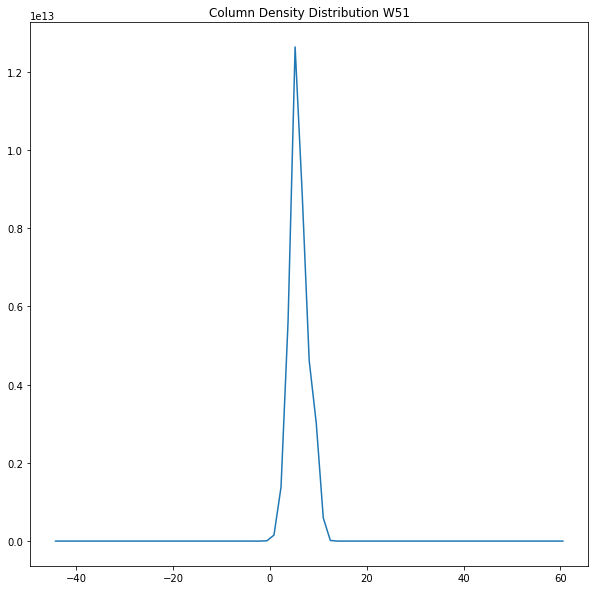

In [90]:
# Plot the Column Density Distribution:
fig, axs = plt.subplots(1, figsize=(10, 10))

axs.plot(velnoh-25, dn_OH_tot)
axs.set_title('Column Density Distribution W51')
#axs.set_xlim([-20, 100])
#axs.set_ylim([0, 0.6e12])

Text(0.5, 1.0, 'W51')

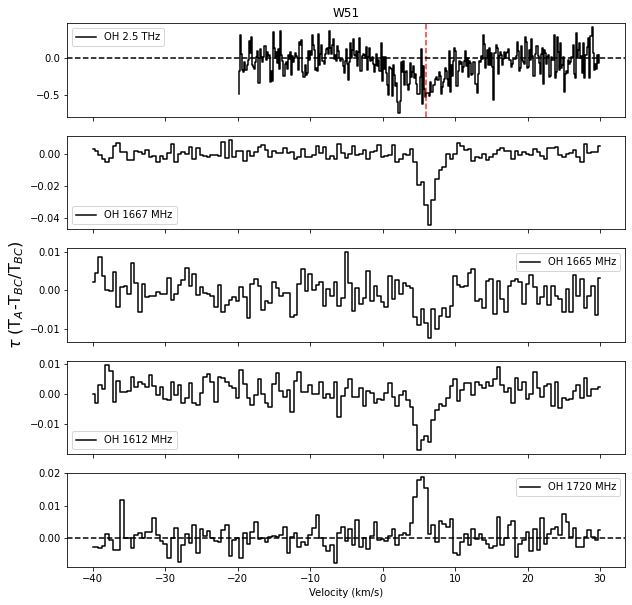

In [91]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(10, 10), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/10.1), 'k', label='OH 2.5 THz', where='mid')
axs[0].axvline(6, ls='dashed', color='r', alpha=0.8)
axs[0].axhline(0, ls='dashed', color='k')
axs[0].legend(loc='best')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[1].legend(loc='best')

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')

axs[3].legend(loc='best')

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W51')

In [92]:
# Try to do the lmfit, create out x,y data:
x = vel67
y = (Ta67-Tc67)/Tc67

# Setup the model:
gmodel = GaussianModel()

# Intitial guess:
pars = gmodel.guess(y, x=x)
result67 = gmodel.fit(y, pars, x=x)
print(result67.fit_report())

[[Model]]
    Model(gaussian)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 147
    # data points      = 141
    # variables        = 3
    chi-square         = 0.00141436
    reduced chi-square = 1.0249e-05
    Akaike info crit   = -1616.88721
    Bayesian info crit = -1608.04093
    R-squared          = 0.76621995
[[Variables]]
    amplitude: -0.08954597 +/- 0.00507290 (5.67%) (init = 5.571837)
    center:     6.41217059 +/- 0.06177761 (0.96%) (init = -5.324818)
    sigma:      0.94437115 +/- 0.06177796 (6.54%) (init = 35)
    fwhm:       2.22382404 +/- 0.14547598 (6.54%) == '2.3548200*sigma'
    height:    -0.03782800 +/- 0.00214303 (5.67%) == '0.3989423*amplitude/max(1e-15, sigma)'
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, sigma) = -0.5774


In [1]:
# Calculate the equivalent width of the gaussian component:

def create_gauss(params, i, q, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Model array:
    gmodel = GaussianModel()
    
    # For i == 0, we label this the 1667 MHz line and call those parameters.
    if i == 0:
        amp = params[f'amp1667_{i+1}_{q}']
        cent = params[f'cen1667_{i+1}_{q}']
        sig = params[f'sig1667_{i+1}_{q}']
        gmodel.make_params(amp=amp, cen=cent, wid=sig)
    
    # For i == 1, we label this the 1665 MHz line and call those parameters.
    elif i == 1:
        amp = params[f'amp1665_{i+1}_{q}']
        cent = params[f'cen1665_{i+1}_{q}']
        sig = params[f'sig1665_{i+1}_{q}']
        gmodel.make_params(amp=amp, cen=cent, wid=sig)
    
    # For i == 2, we label this the 1612 MHz line and call those parameters.
    elif i == 2:
        amp = params[f'amp1612_{i+1}_{q}']
        cent = params[f'cen1612_{i+1}_{q}']
        sig = params[f'sig1612_{i+1}_{q}']
        gmodel.make_params(amp=amp, cen=cent, wid=sig)
            
    # For i == 3, we label this the 1720 MHz line and call those parameters.
    elif i == 3:
        amp = params[f'amp1720_{i+1}_{q}']
        cent = params[f'cen1720_{i+1}_{q}']
        sig = params[f'sig1720_{i+1}_{q}']
        gmodel.make_params(amp=amp, cen=cent, wid=sig)
     
    return gmodel

def gauss(x, amp, cen, sigma):
    """Gaussian lineshape."""
    return amp * np.exp(-(x-cen)**2 / (2.*sigma**2))


def gauss_dataset(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    #amp2 = params[f'amp2_{i+1}']
    #cen2 = params[f'cen2_{i+1}']
    #sig2 = params[f'sig2_{i+1}']
    #amp3 = params[f'amp3_{i+1}']
    #cen3 = params[f'cen3_{i+1}']
    #sig3 = params[f'sig3_{i+1}']
    #amp4 = params[f'amp4_{i+1}']
    #cen4 = params[f'cen4_{i+1}']
    #sig4 = params[f'sig4_{i+1}']
    #amp5 = params[f'amp5_{i+1}']
    #cen5 = params[f'cen5_{i+1}']
    #sig5 = params[f'sig5_{i+1}']
     
    return gauss(x, amp1, cen1, sig1)# + gauss(x, amp2, cen2, sig2)# + gauss(x, amp3, cen3, sig3) + gauss(x, amp4, cen4, sig4)# + gauss(x, amp5, cen5, sig5)

def gauss_dataset_sof(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    #amp2 = params[f'amp2_{i+1}']
    #cen2 = params[f'cen2_{i+1}']
    #sig2 = params[f'sig2_{i+1}']
    amp3 = params[f'amp3_{i+1}']
    cen3 = params[f'cen3_{i+1}']
    sig3 = params[f'sig3_{i+1}']
    amp4 = params[f'amp4_{i+1}']
    cen4 = params[f'cen4_{i+1}']
    sig4 = params[f'sig4_{i+1}']
    #amp5 = params[f'amp5_{i+1}']
    #cen5 = params[f'cen5_{i+1}']
    #sig5 = params[f'sig5_{i+1}']
     
    return gauss(x, amp1, cen1, sig1) + gauss(x, amp3, cen3, sig3) + gauss(x, amp4, cen4, sig4)# + gauss(x, amp5, cen5, sig5)

def gauss_dataset_single(params, i, j, x):
    """Calculate Gaussian lineshape from parameters for data set.
    i = which gaussian component we want to plot (depends on source)
    j = which line is being fit (0=1667, 1=1665, 2=1612, 3=1720)
    x = x axis values """
    amp = params[f'amp{j}_{i+1}']
    cen = params[f'cen{j}_{i+1}']
    sig = params[f'sig{j}_{i+1}']
    
    return gauss(x, amp, cen, sig)

def gauss_dataset_single_n(params, i, j, q, x):
    """Calculate Gaussian lineshape from parameters for data set.
    i = which gaussian component we want to plot (depends on source)
    j = which line is being fit (0=1667, 1=1665, 2=1612, 3=1720)
    q = which gas component
    x = x axis values """
    amp = params[f'amp{j}_{i+1}_{q}']
    cen = params[f'cen{j}_{i+1}_{q}']
    sig = params[f'sig{j}_{i+1}_{q}']
    
    return gauss(x, amp, cen, sig)


def objective(params, x, data):
    """Calculate total residual for fits of Gaussians to several data sets."""
    ndata, _ = data.shape
    resid = 0.0*data[:]

    # make residual per data set
    for i in (1,2,3,4):
        resid[i, :] = data[i, :] - gauss_dataset(params, i, x)
        
    # make residual for sofia data set:
    resid[0, :] = data[0, :] - gauss_dataset_sof(params, 0, x)

    # now flatten this to a 1D array, as minimize() needs
    return resid.flatten()

In [94]:
### This cell is a copy of the above, but made for n gaussians:
def gauss_dataset_n(params, n, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Model array:
    model = []
    
    for q in range(n):
        amp = params[f'amp1_{i+1}_{q}']
        cent = params[f'cen1_{i+1}_{q}']
        sig = params[f'sig1_{i+1}_{q}']
        model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave


def gauss_dataset_sof_n(params, n, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    # Keys to Sofia Guassians:
    keys = [5,6,7]
    # Model array:
    model = []

    for num in keys:
        for q in range(n):
            amp = params[f'amp{num}_{1}_{q}']
            cent = params[f'cen{num}_{1}_{q}']
            sig = params[f'sig{num}_{1}_{q}']
            model.append(gauss(x=x, amp=amp, cen=cent, sigma=sig))
    
    gsave = 0.0*model[0]
    
    for mode in model:
        gsave += mode
     
    return gsave

def objective_sof_n(params, n, velSof, dataSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    velSof = velocity axis
    dataSof = y axis"""
    
    residSof = 0.0*dataSof[:]
    
    # make residual for sofia data set:
    residSof[0,:] = dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof)
    residSof = np.array(residSof)
    
    # now flatten this to a 1D array, as minimize() needs
    return residSof.flatten()

def objective_n(params, n, velVLA, velSof, dataVLA, dataSof):
    """Calculate total residual for fits of Gaussians to several data sets.
    This taks 2 data arrays because the dataSof is a different velocity resolution.
    
    n = number of components
    params = parameters of each gaussian (7 gaussians per component)
    x = velocity axes"""
    ndata, _ = dataVLA.shape
    residVLA = 0.0*dataVLA[:]
    residSof = 0.0*dataSof[:]

    # make residual per VLA data set:
    for i in (0,1,2,3):
        residVLA[i, :] = dataVLA[i, :] - gauss_dataset_n(params, n, i, velVLA)
        
    # make residual for sofia data set:
    residSof[0,:] = dataSof[0,:] - gauss_dataset_sof_n(params, n, velSof)
    
    # Data hacking to get all the data together:
    residVLA = residVLA.flatten()
    residVLA = residVLA.tolist()
    residSof = residSof[0]
    residSof = residSof.tolist()

    # Combine the data together:
    resid = residVLA + residSof
    resid = residVLA
    resid = np.array(resid)
    resid = resid.flatten()

    # now flatten this to a 1D array, as minimize() needs
    return resid

# Add in the Gaussian for 18cm OH data:
def makeVLA(n, dataVLA, fit_params, c0=[0], a1667=[0], a1665=[0], a1612=[0], a1720=[0], s0=[0]):
    for q in range(n):
        for iy, y in enumerate(dataVLA):
            # Gaussian 1667
            if iy == 0:
                fit_params.add(f'amp1_{iy+1}_{q}', value=a1667[q], min=a1667[q]-0.01, max=a1667[q]+0.01)
                fit_params.add(f'cen1_{iy+1}_{q}', value=c0[q], min = c0[q]-1, max = c0[q]+1)
                fit_params.add(f'sig1_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+1)
            elif iy == 1:
                # Gaussian 1665
                fit_params.add(f'amp1_{iy+1}_{q}', value=a1665[q], min=a1665[q]-0.01, max=a1665[q]+0.01)
                fit_params.add(f'cen1_{iy+1}_{q}', value=c0[q], min = c0[q]-1, max = c0[q]+1)
                fit_params.add(f'sig1_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+1)
            elif iy == 2:
                # Gaussian 1612
                fit_params.add(f'amp1_{iy+1}_{q}', value=a1612[q], min=a1612[q]-0.01, max=a1612[q]+0.01)
                fit_params.add(f'cen1_{iy+1}_{q}', value=c0[q], min = c0[q]-1, max = c0[q]+1)
                fit_params.add(f'sig1_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+1)
            elif iy == 3:
                # Gaussian 1720
                fit_params.add(f'amp1_{iy+1}_{q}', value=a1720[q], min=a1720[q]-0.01, max=a1720[q]+0.01)
                fit_params.add(f'cen1_{iy+1}_{q}', value=c0[q], min = c0[q]-1, max = c0[q]+1)
                fit_params.add(f'sig1_{iy+1}_{q}', value=s0[q], min=0, max=s0[q]+1)
        # Set the 
        for iy in (2,3,4):
            fit_params[f'sig1_{iy}_{q}'].expr = f'sig1_1_{q}'
            fit_params[f'cen1_{iy}_{q}'].expr = f'cen1_1_{q}'
        
#Add in the SOFIA Hfs lines:
def makeSOFIA(n, dataSof, fit_params, c0=[0], s0=[0]):
    for q in range(n):
        fit_params.add(f'amp5_1_{q}', value=-0.1, max=0)
        fit_params.add(f'cen5_1_{q}', value=c0[q], min = c0[q]-1, max = c0[q]+1)
        fit_params.add(f'sig5_1_{q}', value=s0[q], min=0, max=s0[q]+1)

        fit_params.add(f'amp6_1_{q}', value=-0.1, max=0)
        fit_params.add(f'cen6_1_{q}', value=c0[q]+2.2)
        fit_params.add(f'sig6_1_{q}', value=s0[q], min=0, max=s0[q]+1)

        fit_params.add(f'amp7_1_{q}', value=-0.1, max=0)
        fit_params.add(f'cen7_1_{q}', value=c0[q]-4.4)
        fit_params.add(f'sig7_1_{q}', value=s0[q], min=0, max=s0[q]+1)

        # First HFS Gaussian:
        fit_params[f'sig5_1_{q}'].expr = f'sig1_1_{q}'
        fit_params[f'cen5_1_{q}'].expr = f'cen1_1_{q}'
    
        # Second HFS Gaussian
        fit_params[f'amp6_1_{q}'].expr = f'0.071* amp5_1_{q}'
        fit_params[f'sig6_1_{q}'].expr = f'sig5_1_{q}'
        fit_params[f'cen6_1_{q}'].expr = f'cen5_1_{q}+2.2'
        # Third HFS Gaussian
        fit_params[f'amp7_1_{q}'].expr = f'0.64* amp5_1_{q}'
        fit_params[f'sig7_1_{q}'].expr = f'sig5_1_{q}'
        fit_params[f'cen7_1_{q}'].expr = f'cen5_1_{q}-4.4'

In [95]:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/10.1)]
dataSof = np.array(dataSof)

In [107]:
# For multiple components:

# Number of gas components:
n = 2

# Figure of Merits:
aic = []
bic = []

# Add in intitial guesses
c0 = [4.5, 7]
s0 = [3, 3]
a1667 = [-0.03, -0.04]
a1665 = [-0.005, -0.01]
a1612 = [-0.015, -0.010]
a1720 = [0.015, 0.005]

# Add in sigma guess from 18cm line:

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720, s0)
makeSOFIA(n, dataSof, fit_params, c0, s0)

# Do the fitting
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof))
report_fit(out)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 643
    # data points      = 564
    # variables        = 14
    chi-square         = 0.00625340
    reduced chi-square = 1.1370e-05
    Akaike info crit   = -6407.06157
    Bayesian info crit = -6346.37082
##  Warning: uncertainties could not be estimated:
    amp1_1_0:  at boundary
    amp5_1_0:  at initial value
    amp5_1_1:  at initial value
[[Variables]]
    amp1_1_0: -0.02000000 (init = -0.03)
    cen1_1_0:  5.25958060 (init = 4.5)
    sig1_1_0:  0.65585254 (init = 3)
    amp1_2_0: -0.00708506 (init = -0.005)
    cen1_2_0:  5.25958060 == 'cen1_1_0'
    sig1_2_0:  0.65585254 == 'sig1_1_0'
    amp1_3_0: -0.01726994 (init = -0.015)
    cen1_3_0:  5.25958060 == 'cen1_1_0'
    sig1_3_0:  0.65585254 == 'sig1_1_0'
    amp1_4_0:  0.02099684 (init = 0.015)
    cen1_4_0:  5.25958060 == 'cen1_1_0'
    sig1_4_0:  0.65585254 == 'sig1_1_0'
    amp1_1_1: -0.03749584 (init = -0.04)
    cen1_1_1:  6.70263962 (init = 7)


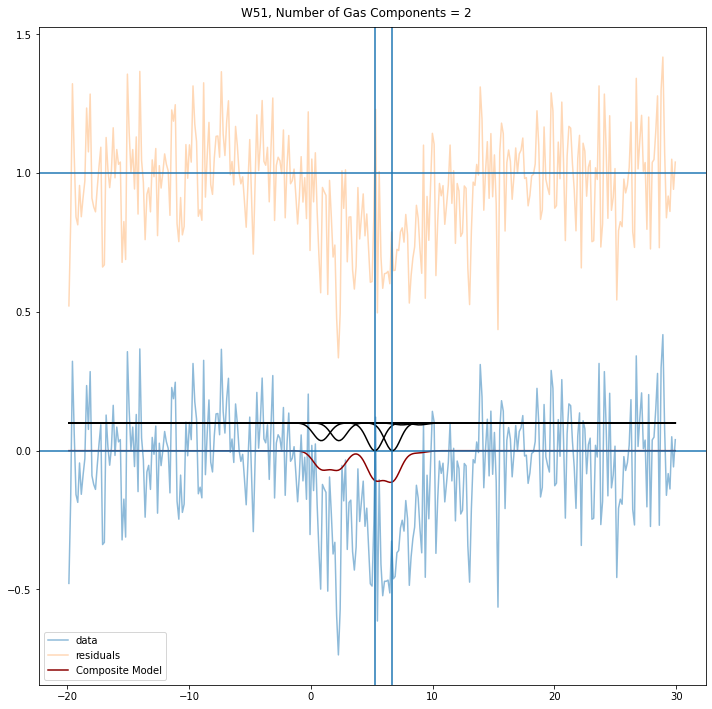

In [98]:
fig = plt.figure(figsize=(10,10))
fig.suptitle('W51, Number of Gas Components = ' + str(n))

plt.plot(VelSof, TaSof/10.1, alpha=0.5, label='data')
plt.plot(VelSof, (TaSof/10.1-gauss_dataset_sof_n(n=n, params=out.params, x=VelSof)+1), alpha=0.3, label='residuals')
plt.plot(VelSof, gauss_dataset_sof_n(n=n, params=out.params, x=VelSof), color='darkred', label='Composite Model')
plt.axhline(1)
plt.axhline(0)

for i in range(n):
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof)+0.1, color='black')
    
    
plt.axvline(out.params['cen5_1_0'].value)
plt.axvline(out.params['cen5_1_1'].value)
#plt.axvline(out.params['cen5_1_2'].value)

fig.tight_layout()
plt.legend()

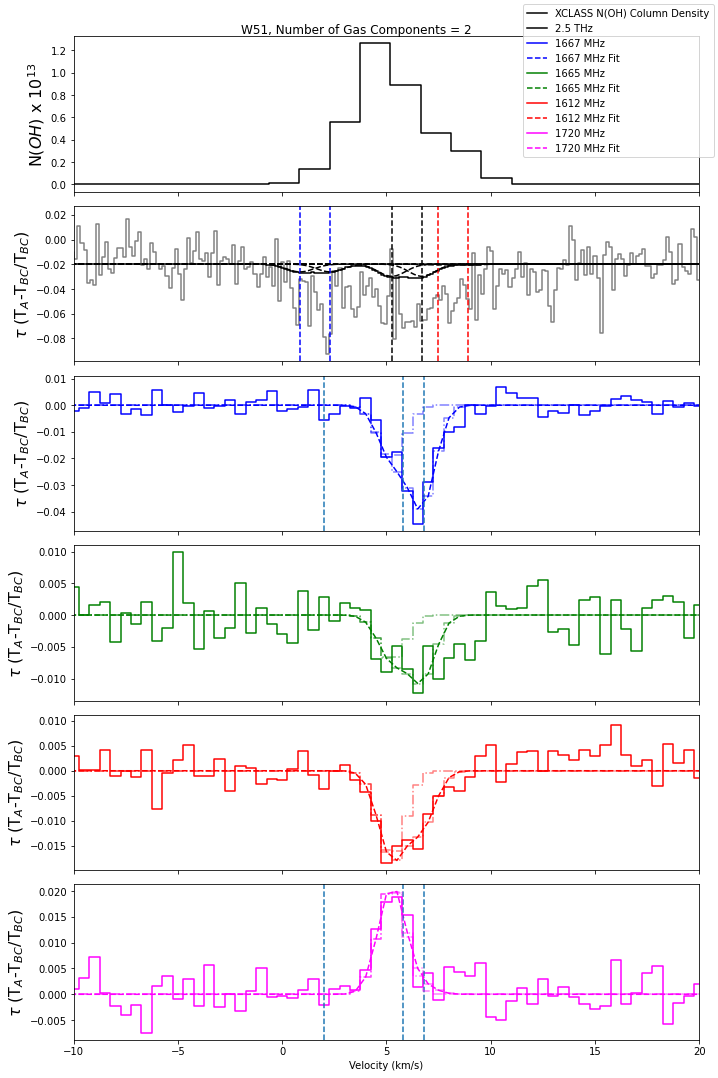

In [99]:
# Set the x axis:
x = vel67

# Get the best fit for plotting:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, x)
y_fit65 = gauss_dataset_n(out.params, n, 1, x)
y_fit12 = gauss_dataset_n(out.params, n, 2, x)
y_fit20 = gauss_dataset_n(out.params, n, 3, x)

# Plotting the Data and Models:
fig, axs = plt.subplots(6, figsize=(10,15), sharex='all')
fig.suptitle('W51, Number of Gas Components = ' + str(n))

axs[0].step(velnoh-25, dn_OH_tot/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)

axs[1].step(VelSof, (dataSof[0,:]-0.2)/10.1, color='BLACK', alpha=0.5)
axs[1].step(VelSof, (y_fitsof-0.2)/10.1, color='Black', label='2.5 THz')
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)

axs[1].axvline(out.params['cen5_1_0'].value, ls='dashed', color='k')
axs[1].axvline(out.params['cen6_1_0'].value, ls='dashed', color='r')
axs[1].axvline(out.params['cen7_1_0'].value, ls='dashed', color='b')

axs[1].axvline(out.params['cen5_1_1'].value, ls='dashed', color='k')
axs[1].axvline(out.params['cen6_1_1'].value, ls='dashed', color='r')
axs[1].axvline(out.params['cen7_1_1'].value, ls='dashed', color='b')

#axs[1].axvline(out.params['cen5_1_1'].value)

for i in range(n):
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof)-0.2)/10.1, color='black', ls='dashed')
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof)-0.2)/10.1, color='black', ls='dashed')
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof)-0.2)/10.1, color='black', ls='dashed')

axs[2].step(x, dataVLA[0,:], color='BLUE', label='1667 MHz', where='mid')
axs[2].plot(x, y_fit67, color='BLUE', label='1667 MHz Fit', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].axvline(2, ls='dashed')
axs[2].axvline(5.8, ls='dashed')
axs[2].axvline(6.8, ls='dashed')
for i in range(n):
    axs[2].step(x, gauss_dataset_n(out.params, i+1, 0, x), color='BLUE', ls='-.', alpha=0.5, where='mid')

axs[3].step(x, dataVLA[1,:], color='GREEN', label='1665 MHz', where='mid')
axs[3].plot(x, y_fit65, color='GREEN', label='1665 MHz Fit', ls='dashed')
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[3].step(x, gauss_dataset_n(out.params, i+1, 1, x), alpha=0.5, color='GREEN', ls='-.', where='mid')

axs[4].step(x, dataVLA[2,:], color='RED', label='1612 MHz', where='mid')
axs[4].plot(x, y_fit12, color='RED', label='1612 MHz Fit', ls='dashed')
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[4].step(x, gauss_dataset_n(out.params, i+1, 2, x), color='RED', ls='-.',  alpha=0.5, where='mid')

axs[5].step(x, dataVLA[3,:], color='MAGENTA', label='1720 MHz', where='mid')
axs[5].plot(x, y_fit20, color='MAGENTA', label='1720 MHz Fit', ls='dashed')
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[5].axvline(2, ls='dashed')
axs[5].axvline(5.8, ls='dashed')
axs[5].axvline(6.8, ls='dashed')

for i in range(n):
    axs[5].step(x, gauss_dataset_n(out.params, i+1, 3, x), color='MAGENTA', alpha=0.5, ls='-.', where='mid')


plt.xlim([-10, 20])
plt.xlabel('Velocity (km/s)')
fig.legend(loc='upper right')
fig.tight_layout()
#plt.savefig('GeneralizedFittingn=2.png', format='png')

In [100]:
# Interpolate the Sofia data to regrid onto the VLA xaxis:
TaSof_regrid = np.interp(vel67, VelSof, TaSof)

data = [(TaSof_regrid/10.1), ((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
data = np.array(data)

In [101]:
# For a single component: 18cm and Sofia:
fit_params = Parameters()
for iy, y in enumerate(data):
    # First Gaussian
    fit_params.add(f'amp1_{iy+1}', value=0, min=-1, max=1)
    fit_params.add(f'cen1_{iy+1}', value=6, min=3, max=8)
    fit_params.add(f'sig1_{iy+1}', value=0.5, min=-10, max=10)
    # Second Gaussian
    #fit_params.add(f'amp2_{iy+1}', value=0, min=-1, max=1)
    #fit_params.add(f'cen2_{iy+1}', value=6, min=-15, max=15)
    #fit_params.add(f'sig2_{iy+1}', value=0.5, min=-10, max=10)
    # Third Gaussian
    #fit_params.add(f'amp3_{iy+1}', value=0, min=-1, max=1)
    #fit_params.add(f'cen3_{iy+1}', value=6, min=-15, max=15)
    #fit_params.add(f'sig3_{iy+1}', value=0.5, min=-10, max=10)
    # Fourth Gaussian
    #fit_params.add(f'amp4_{iy+1}', value=0, min=-1, max=1)
    #fit_params.add(f'cen4_{iy+1}', value=6, min=-15, max=15)
    #fit_params.add(f'sig4_{iy+1}', value=0.5, min=-10, max=10)
    # Five Gaussian
    #fit_params.add(f'amp5_{iy+1}', value=0, min=-1, max=1)
    #fit_params.add(f'cen5_{iy+1}', value=6-4.4, min=-15, max=15)
    #fit_params.add(f'sig5_{iy+1}', value=0.5, min=-10, max=10)
    
#Add in the SOFIA Hfs lines:
fit_params.add(f'amp3_1', value=0, min=-1, max=1)
fit_params.add(f'cen3_1', value=6+2.07, min=-10, max=15)
fit_params.add(f'sig3_1', value=0.5, min=-10, max=10)

fit_params.add(f'amp4_1', value=0, min=-1, max=1)
fit_params.add(f'cen4_1', value=6-4.4, min=-10, max=15)
fit_params.add(f'sig4_1', value=0.5, min=-10, max=10)

# Set all FWHM, center to be the same:
for iy in (2,3,4,5):
    # First Gaussian
    fit_params[f'sig1_{iy}'].expr = 'sig1_1'
    fit_params[f'cen1_{iy}'].expr = 'cen1_1'
    # Second Gaussian
    #fit_params[f'sig2_{iy}'].expr = 'sig2_1'
    #fit_params[f'cen2_{iy}'].expr = 'cen2_1'
    # Third Gaussian
    #fit_params[f'sig3_{iy}'].expr = 'sig3_1'
    #fit_params[f'cen3_{iy}'].expr = 'cen3_1'
    # Fourth Gaussian
    #fit_params[f'sig4_{iy}'].expr = 'sig4_1'
    #fit_params[f'cen4_{iy}'].expr = 'cen4_1'
    # Five Gaussian
    #fit_params[f'sig5_{iy}'].expr = 'sig5_1'
    #fit_params[f'cen5_{iy}'].expr = 'cen5_1'
    
# First Gaussian
fit_params[f'sig3_1'].expr = 'sig1_1'
fit_params[f'cen3_1'].expr = 'cen1_1+2.2'
# Second Gaussian
fit_params[f'sig4_1'].expr = 'sig1_1'
fit_params[f'cen4_1'].expr = 'cen1_1-4.4'

In [102]:
out = minimize(objective, fit_params, args=(vel67, data))
report_fit(out.params)

[[Variables]]
    amp1_1: -0.41322112 +/- 0.09743374 (23.58%) (init = 0)
    cen1_1:  6.34588153 +/- 1.09181126 (17.21%) (init = 6)
    sig1_1:  1.98131763 +/- 0.48143383 (24.30%) (init = 0.5)
    amp1_2: -0.02322632 +/- 0.04720137 (203.22%) (init = 0)
    cen1_2:  6.34588153 +/- 1.09181126 (17.21%) == 'cen1_1'
    sig1_2:  1.98131763 +/- 0.48143383 (24.30%) == 'sig1_1'
    amp1_3: -0.00842567 +/- 0.04712807 (559.34%) (init = 0)
    cen1_3:  6.34588153 +/- 1.09181126 (17.21%) == 'cen1_1'
    sig1_3:  1.98131763 +/- 0.48143383 (24.30%) == 'sig1_1'
    amp1_4: -0.01178304 +/- 0.04713869 (400.06%) (init = 0)
    cen1_4:  6.34588153 +/- 1.09181126 (17.21%) == 'cen1_1'
    sig1_4:  1.98131763 +/- 0.48143383 (24.30%) == 'sig1_1'
    amp1_5:  0.00997175 +/- 0.04713252 (472.66%) (init = 0)
    cen1_5:  6.34588153 +/- 1.09181126 (17.21%) == 'cen1_1'
    sig1_5:  1.98131763 +/- 0.48143383 (24.30%) == 'sig1_1'
    amp3_1: -0.04298954 +/- 0.20267331 (471.45%) (init = 0)
    cen3_1:  8.54588153 +/-

In [103]:
# Single Component:
# Chi Squared 0.00526
# Bayesian Info Crit. -4508

# Three Component:
# Chi Squared: 0.00426
# -4521
out

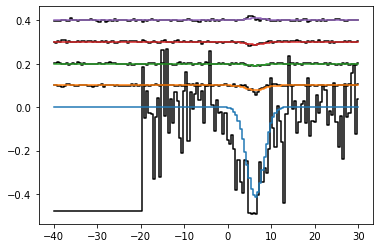

In [104]:
plt.figure()
for i in range(5):
    y_fit = gauss_dataset(out.params, i, x)
    plt.step(x, data[i, :]+i/10, 'k', x, y_fit+i/10, '-', where='mid')

In [105]:
# Set the x axis:
x = vel67

# Get the best fit for plotting:
y_fitsof = gauss_dataset_sof(out.params, 0, x)
y_fit67 = gauss_dataset(out.params, 1, x)
y_fit65 = gauss_dataset(out.params, 2, x)
y_fit12 = gauss_dataset(out.params, 3, x)
y_fit20 = gauss_dataset(out.params, 4, x)

# Get the separate components for plotting:
#i = which gaussian component we want to plot (depends on source)
#j = which line is being fit (0=sof, 1=1667, 2=1665, 3=1612, 4=1720)
# ampj_i
y_fit1_sof = gauss_dataset_single(out.params, 0, 1, x)
#y_fit2_sof = gauss_dataset_single(out.params, 0, 2, x)
y_fit3_sof = gauss_dataset_single(out.params, 0, 3, x)
y_fit4_sof = gauss_dataset_single(out.params, 0, 4, x)

y_fit1_67 = gauss_dataset_single(out.params, 1, 1, x)
#y_fit1_67 = gauss_dataset_single(out.params, 1, 2, x)

y_fit1_65 = gauss_dataset_single(out.params, 2, 1, x)
#y_fit2_65 = gauss_dataset_single(out.params, 2, 2, x)

y_fit1_12 = gauss_dataset_single(out.params, 3, 1, x)
#y_fit2_12 = gauss_dataset_single(out.params, 3, 2, x)

y_fit1_20 = gauss_dataset_single(out.params, 4, 1, x)
#y_fit2_20 = gauss_dataset_single(out.params, 4, 2, x)

Text(0.5, 1.0, 'W51')

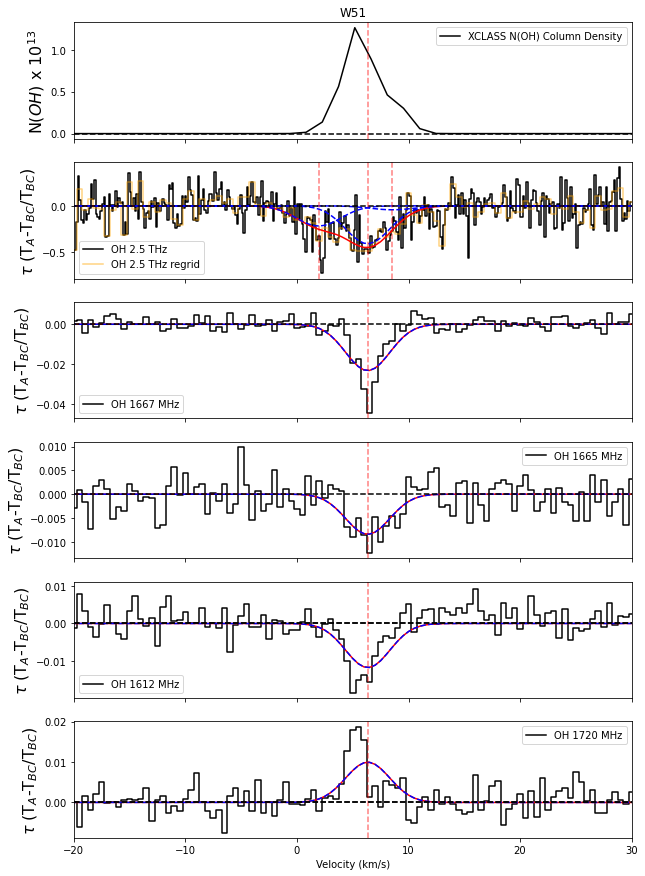

In [106]:
# Plot the data and the fits:
fig, axs = plt.subplots(6, figsize=(10, 15), sharex='all')

# Plot the OH:
axs[0].plot(velnoh-25, dn_OH_tot/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[0].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)
axs[0].set_xlim([-20, 30])
axs[0].legend(loc='best')

axs[1].step(VelSof, (TaSof/10.1), 'k', label='OH 2.5 THz', where='mid')
axs[1].step(vel67, (TaSof_regrid/10.1), 'orange', label='OH 2.5 THz regrid', where='mid', alpha=0.5)
axs[1].plot(vel67, y_fitsof, color='r', ls='solid')
axs[1].plot(vel67, y_fit1_sof, color='b', ls='dashed')
#axs[1].plot(vel67, y_fit2_sof, color='b', ls='dashed')
axs[1].plot(vel67, y_fit3_sof, color='b', ls='dashed')
axs[1].plot(vel67, y_fit4_sof, color='b', ls='dashed')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
axs[1].axvline(out.params['cen3_1'].value, color='r', ls='dashed', alpha=0.5)
axs[1].axvline(out.params['cen4_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[1].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[1].legend(loc='best')

axs[2].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
axs[2].plot(vel67, y_fit67, color='r', ls='solid')
axs[2].plot(vel67, y_fit1_67, color='b', ls='dashed')
#axs[2].plot(vel67, y_fit2_67, color='b', ls='dashed')
axs[2].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[2].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
axs[3].plot(vel65, y_fit65, color='r', ls='solid')
axs[3].plot(vel65, y_fit1_65, color='b', ls='dashed')
#axs[3].plot(vel65, y_fit2_65, color='b', ls='dashed')
axs[3].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[3].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[3].axhline(0, color='k', ls='dashed')
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[3].legend(loc='best')

axs[4].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
axs[4].plot(vel12, y_fit12, color='r', ls='solid')
axs[4].plot(vel12, y_fit1_12, color='b', ls='dashed')
#axs[4].plot(vel12, y_fit2_12, color='b', ls='dashed')
axs[4].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[4].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

axs[5].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
axs[5].plot(vel20, y_fit20, color='r', ls='solid')
axs[5].plot(vel20, y_fit1_20, color='b', ls='dashed')
#axs[5].plot(vel20, y_fit2_20, color='b', ls='dashed')
axs[5].axvline(out.params['cen1_1'].value, color='r', ls='dashed', alpha=0.5)
#axs[5].axvline(out.params['cen2_1'].value, color='r', ls='dashed', alpha=0.5)
axs[5].axhline(0, color='k', ls='dashed')
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[5].axhline(0, color='k', ls='dashed')
axs[5].legend(loc='best')

plt.xlabel('Velocity (km/s)')
fig.savefig("W51_OneComponent.png", format='png')
axs[0].set_title('W51')

In [ ]:
#for iy in (1, 2, 3, 4):
#    print(iy)
#    print(out.params[f'cen1_{iy}'])
#    print(out.params[f'sig1_{iy}'])
    #print(out.params[f'amp2_{iy}']/out.params[f'amp2_1'])
    #print(out.params[f'amp3_{iy}']/out.params[f'amp3_1'])
    
print(out.params[f'cen1_1'])
print(out.params[f'sig1_1'])
print(out.params[f'cen2_1'])
print(out.params[f'sig2_1'])

In [ ]:
# For default bounds, add upper and lower on other calls:

#EWSofiaW51 = ew(VelSof, TaSof/10.1, upper = out.params[f'cen1_1'].value + 3*out.params[f'sig1_1'].value, lower = out.params[f'cen1_1'].value - 3*out.params[f'sig1_1'].value)

# RMS calculation:
EWsofW51_rms = rms(VelSof, TaSof/10.1, upper = -5, lower = -20)
EW67W51_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 0, lower = -35)
EW65W51_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 0, lower = -35)
EW12W51_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 0, lower = -35)
EW20W51_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 0, lower = -35)

# Equivalent Width calculation:
EWsofW51 = ew(VelSof, TaSof/10.1, rms=EWsofW51_rms, upper = 10, lower = 0)
EW67W51 = ew(vel67, (Ta67-Tc67)/Tc67, rms=EW67W51_rms, upper = 10, lower = 0)
EW65W51 = ew(vel65, (Ta65-Tc65)/Tc65, rms=EW65W51_rms, upper = 10, lower = 0)
EW12W51 = ew(vel12, (Ta12-Tc12)/Tc12, rms=EW12W51_rms, upper = 10, lower = 0)
EW20W51 = ew(vel20, (Ta20-Tc20)/Tc20, rms=EW20W51_rms, upper = 10, lower = 0)

# Error in EW:

# Equivalent Width:
print("Central Velocity:" + str(out.params['cen1_1'].value) + ' sigma= ' + str(out.params['sig1_1'].value))
print(EWsofW51)
print(EW67W51)
print(EW65W51)
print(EW12W51)
print(EW20W51)

# Set noh:
#nohtot = 1.4e14

# Excitation Temperatures:
print("\n")
ex67w51 = ex(EW67W51[0], columnDensity, 67)
ex65w51 = ex(EW65W51[0], columnDensity, 65)
ex12w51 = ex(EW12W51[0], columnDensity, 12)
ex20w51 = ex(EW20W51[0], columnDensity, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67w51_err = np.abs(ex67w51) * np.sqrt((EW67W51[1]/EW67W51[0])**2 + (0.05e13/columnDensity)**2)
ex65w51_err = np.abs(ex65w51) * np.sqrt((EW65W51[1]/EW65W51[0])**2 + (0.05e13/columnDensity)**2)
ex12w51_err = np.abs(ex12w51) * np.sqrt((EW12W51[1]/EW12W51[0])**2 + (0.05e13/columnDensity)**2)
ex20w51_err = np.abs(ex20w51) * np.sqrt((EW20W51[1]/EW20W51[0])**2 + (0.05e13/columnDensity)**2)

#Print out results:
print("Tex for 1667 is: " + str(-ex67w51) + " +/- " + str(ex67w51_err))
print("Tex for 1665 is: " + str(-ex65w51) + " +/- " + str(ex65w51_err))
print("Tex for 1612 is: " + str(-ex12w51) + " +/- " + str(ex12w51_err))
print("Tex for 1720 is: " + str(-ex20w51) + " +/- " + str(ex20w51_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12w51/ex67w51)
print(ex65w51/ex67w51)
print(ex67w51/ex67w51)
print(ex20w51/ex67w51)

In [ ]:
# Append results to table:
dataTable.add_row(("W51", out.params['cen1_1'].value, out.params['sig1_1'].value,
                  -ex12w51, ex12w51_err,
                  -ex65w51, ex65w51_err,
                  -ex67w51, ex67w51_err,
                  -ex20w51, ex20w51_err,
                  EWsofW51[0], EWsofW51[1],
                  EW12W51[0], EW12W51[1],
                  EW65W51[0], EW65W51[1],
                  EW67W51[0], EW67W51[1],
                  EW20W51[0], EW20W51[1],
                  columnDensity
                 ))

In [ ]:
dataTable

In [ ]:
datTable = pd.DataFrame()

### Now we will do W49N:

In [44]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W49N_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
#w49noh_2 = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')
w49noh_real = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W49N.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= 45) & (VelSof <= 80))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/w49N/w49N.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']
velnoh = w49noh_real['col1']
noh = w49noh_real['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= 45) & (vel67 <= 100))
igood65 = np.where((vel65 >= 45) & (vel65 <= 100))
igood12 = np.where((vel12 >= 45) & (vel12 <= 100))
igood20 = np.where((vel20 >= 45) & (vel20 <= 100))
igoodnoh = np.where((velnoh-25 >= 45) & (velnoh-25 <= 80))

# Choose a continuum.
igood67c = np.where((vel67 >= 45) & (vel67 <= 100))
igood65c = np.where((vel65 >= 45) & (vel65 <= 100))
igood12c = np.where((vel12 >= 45) & (vel12 <= 100))
igood20c = np.where((vel20 >= 45) & (vel20 <= 100))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]

w49noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_W49N.molfit')

Area_OH = w49noh['col1']

mu_OH = w49noh['col3']

sigma_OH = w49noh['col2']/2.3

A_OH = Area_OH/(w49noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(velnoh, A_OH[i], mu_OH[i], sigma_OH[i])


# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# Component 1:
igoodnoh = np.where((velnoh-25 >= 38) & (velnoh-25 <= 42))
columnDensity1 = np.sum(dn_OH_tot[igoodnoh])*delta

# Component 2:
igoodnoh = np.where((velnoh-25 >= 58) & (velnoh-25 <= 60))
columnDensity2 = np.sum(dn_OH_tot[igoodnoh])*delta

# Component 3:
igoodnoh = np.where((velnoh-25 >= 60) & (velnoh-25 <= 62))
columnDensity3 = np.sum(dn_OH_tot[igoodnoh])*delta

In [45]:
# Column Density for Component 1:
columnDensity1*u.cm**-2

<Quantity 1.4378856e+14 cm2>

In [46]:
# Column Density for Component 2:
columnDensity2*u.cm**-2

<Quantity 4.74920833e+13 cm2>

In [47]:
# Column Density for Component 3:
columnDensity3*u.cm**-2

<Quantity 4.45668644e+13 cm2>

In [48]:
# Perform a Gaussian fit around the center velocity of the identified clouds:

# Assign data to data aray for fitting:
data = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
data = np.array(data)

# How many Gaussians are we going to use?
def gauss_dataset(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    amp2 = params[f'amp2_{i+1}']
    cen2 = params[f'cen2_{i+1}']
    sig2 = params[f'sig2_{i+1}']
    amp3 = params[f'amp3_{i+1}']
    cen3 = params[f'cen3_{i+1}']
    sig3 = params[f'sig3_{i+1}']
    
    return gauss(x, amp1, cen1, sig1) + gauss(x, amp2, cen2, sig2) + gauss(x, amp3, cen3, sig3)# + gauss(x, amp4, cen4, sig4) + gauss(x, amp5, cen5, sig5)

# Create the fitters:
fit_params = Parameters()
for iy, y in enumerate(data):
    # First Gaussian
    fit_params.add(f'amp1_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen1_{iy+1}', value=39, min=34, max=44)
    fit_params.add(f'sig1_{iy+1}', value=0.5, min=0.01, max=2.0)
    # Second Gaussian
    fit_params.add(f'amp2_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen2_{iy+1}', value=60, min=50, max=69)
    fit_params.add(f'sig2_{iy+1}', value=0.5, min=0.01, max=12)
     # Third Gaussian
    fit_params.add(f'amp3_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen3_{iy+1}', value=57, min=50, max=69)
    fit_params.add(f'sig3_{iy+1}', value=0.5, min=0.01, max=12)

# Set all FWHM, center to be the same:
for iy in (2,3,4):
    # First Gaussian
    fit_params[f'sig1_{iy}'].expr = 'sig1_1'
    fit_params[f'cen1_{iy}'].expr = 'cen1_1'
    # Second Gaussian
    fit_params[f'sig2_{iy}'].expr = 'sig2_1'
    fit_params[f'cen2_{iy}'].expr = 'cen2_1'
    # Thid Gaussian
    fit_params[f'sig3_{iy}'].expr = 'sig3_1'
    fit_params[f'cen3_{iy}'].expr = 'cen3_1'

In [49]:
# Perform a fit:
#out = minimize(objective, fit_params, args=(vel67, data))
#report_fit(out.params)

In [50]:
#plt.step(velnoh-25, dn_OH_tot/1e14)
#plt.step(VelSof, TaSof/8.2)
#plt.xlim([30, 70])
#plt.axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
#plt.axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
#plt.axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
#plt.ylim([0, 0.4e15])

In [51]:
#plt.figure()
#for i in range(4):
#    y_fit = gauss_dataset(out.params, i, vel67)
#    plt.step(vel67, data[i, :], 'k', vel67, y_fit, '-')
    
# Get the best fit for plotting:
#y_fit67 = gauss_dataset(out.params, 0, vel67)
#y_fit65 = gauss_dataset(out.params, 1, vel67)
#y_fit12 = gauss_dataset(out.params, 2, vel67)
#y_fit20 = gauss_dataset(out.params, 3, vel67)

In [52]:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/8)]
dataSof = np.array(dataSof)

In [53]:
# For multiple components:
aic = []

# Number of gas components:
for i in range(10):
    n = i+1

    # Add in intitial guesses
    p0 = [50,50,50,50,50,50,50,50,50,50]

    # Instantiate fit parameters:
    fit_params = Parameters()

    # Set parameters:
    makeVLA(n, dataVLA, fit_params, p0)
    makeSOFIA(n, dataSof, fit_params, p0)

    # Do the fitting:
    out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof))
    report_fit(out)

    # Save the AIC:
    aic.append(out.aic)

ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

In [54]:
aic

[]

Text(0.5, 0, '# of Components')

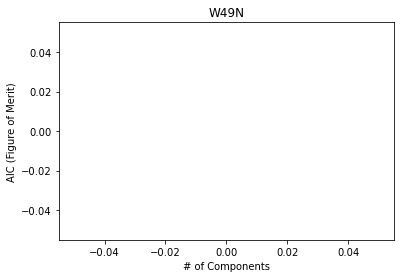

In [55]:
plt.plot(aic, ls='', marker='*')
plt.title('W49N')
plt.ylabel('AIC (Figure of Merit)')
plt.xlabel('# of Components')

In [56]:
# For W49 it appears that it is most preferred:
n=2

# Add in intitial guesses for central velocity
c0 = [58, 61, 64]
a1667 = [-0.02, -0.05, -0.03]
a1665 = [-0.015, -0.02, -0.02]
a1612 = [-0.015, 0.02, -0.015]
a1720 = [0.03, -0.01, -0.01]

# Add in intiial guess for amplitude (for each individual one)

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, c0, a1667, a1665, a1612, a1720)
makeSOFIA(n, dataSof, fit_params, c0)

# Do the fitting:
out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof))
report_fit(out)

IndexError: list index out of range

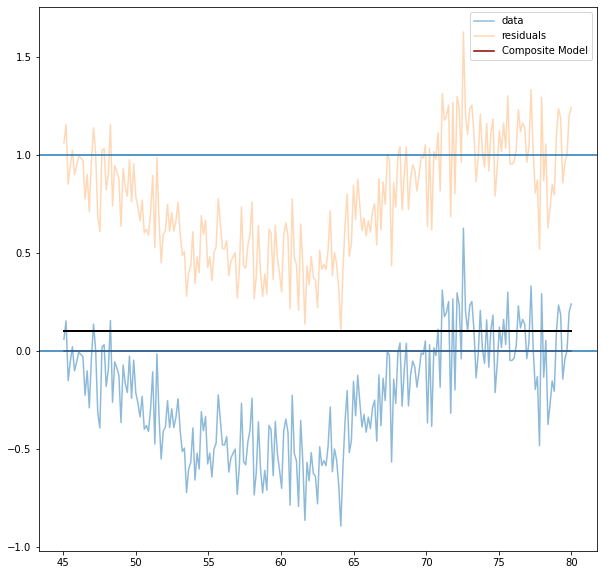

In [57]:
# We were able to fit 2 components (6 gaussians)!
fig = plt.figure(figsize=(10,10))

plt.plot(VelSof, TaSof/8, alpha=0.5, label='data')
plt.plot(VelSof, (TaSof/8-gauss_dataset_sof_n(n=n, params=out.params, x=VelSof)+1), alpha=0.3, label='residuals')
plt.plot(VelSof, gauss_dataset_sof_n(n=n, params=out.params, x=VelSof), color='darkred', label='Composite Model')
plt.axhline(1)
plt.axhline(0)

for i in range(n):
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof)+0.1, color='black')

#plt.axvline(out.params['cen5_1_0'].value)
#plt.axvline(out.params['cen5_1_1'].value)
#plt.axvline(out.params['cen5_1_2'].value)

#plt.axvline(47.4, ls='dashed', color='k')
#plt.axvline(62.3, ls='dashed', color='k')
#plt.axvline(56.7, ls='dashed', color='k')
#plt.axvline(67.5, ls='dashed', color='k')
#plt.axvline(75, ls='dashed', color='k')

plt.legend()

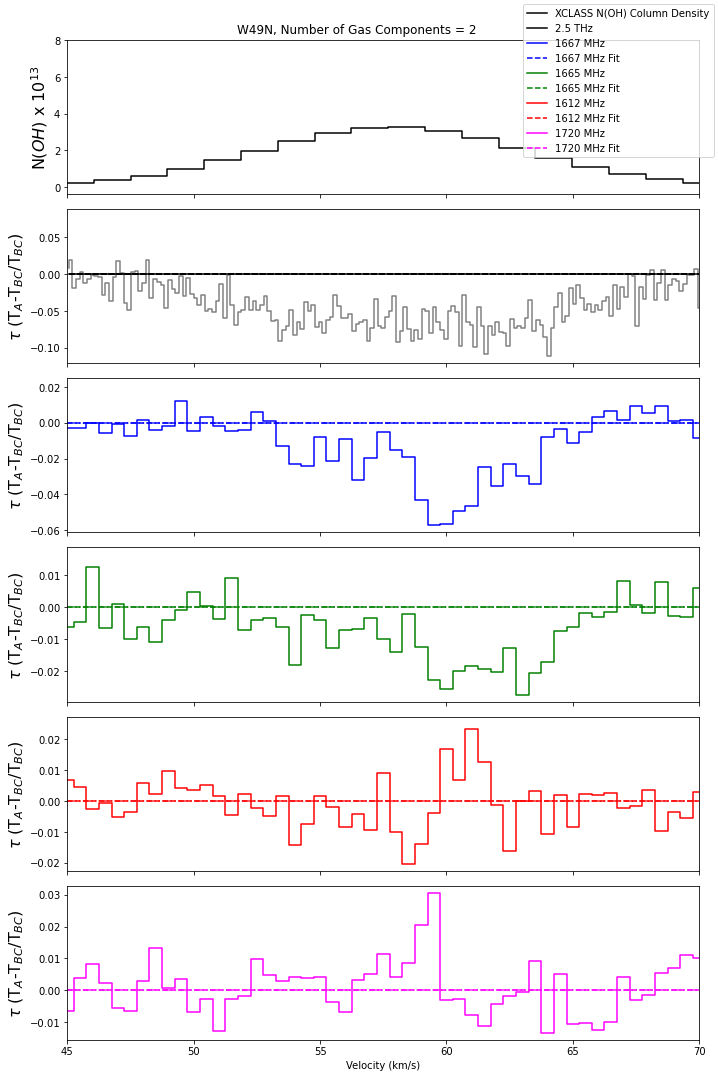

In [58]:
# Set the x axis:
x = vel67

# Get the best fit for plotting:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, x)
y_fit65 = gauss_dataset_n(out.params, n, 1, x)
y_fit12 = gauss_dataset_n(out.params, n, 2, x)
y_fit20 = gauss_dataset_n(out.params, n, 3, x)

# Plotting the Data and Models:
fig, axs = plt.subplots(6, figsize=(10,15), sharex='all')
fig.suptitle('W49N, Number of Gas Components = ' + str(n))

axs[0].step(velnoh-25, dn_OH_tot/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)

axs[1].step(VelSof, (dataSof[0,:])/8, color='BLACK', alpha=0.5)
axs[1].step(VelSof, (y_fitsof)/8, color='Black', label='2.5 THz')
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)

for i in range(n):
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof))/8, color='black', ls='dashed')
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof))/8, color='black', ls='dashed')
    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof))/8, color='black', ls='dashed')

axs[2].step(x, dataVLA[0,:], color='BLUE', label='1667 MHz', where='mid')
axs[2].plot(x, y_fit67, color='BLUE', label='1667 MHz Fit', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[2].step(x, gauss_dataset_n(out.params, i+1, 0, x), color='BLUE', ls='-.', alpha=0.5, where='mid')

axs[3].step(x, dataVLA[1,:], color='GREEN', label='1665 MHz', where='mid')
axs[3].plot(x, y_fit65, color='GREEN', label='1665 MHz Fit', ls='dashed')
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[3].step(x, gauss_dataset_n(out.params, i+1, 1, x), alpha=0.5, color='GREEN', ls='-.', where='mid')

axs[4].step(x, dataVLA[2,:], color='RED', label='1612 MHz', where='mid')
axs[4].plot(x, y_fit12, color='RED', label='1612 MHz Fit', ls='dashed')
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[4].step(x, gauss_dataset_n(out.params, i+1, 2, x), color='RED', ls='-.',  alpha=0.5, where='mid')

axs[5].step(x, dataVLA[3,:], color='MAGENTA', label='1720 MHz', where='mid')
axs[5].plot(x, y_fit20, color='MAGENTA', label='1720 MHz Fit', ls='dashed')
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
for i in range(n):
    axs[5].step(x, gauss_dataset_n(out.params, i+1, 3, x), color='MAGENTA', alpha=0.5, ls='-.', where='mid')

#plt.axvline(out.params['cen1_1_0'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_1'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_2'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_3'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_4'].value, alpha=0.5, ls='dashed')

plt.xlim([45, 70])
plt.xlabel('Velocity (km/s)')
fig.legend(loc='upper right')
fig.tight_layout()
#plt.savefig('GeneralizedFittingn=2.png', format='png')

In [ ]:
# Plot the data:
fig, axs = plt.subplots(5, figsize=(10, 8), sharex='all')

# Plot the OH:
axs[0].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(39, ls='dashed', color='r', alpha=0.8)
axs[0].axvline(60, ls='dashed', color='r', alpha=0.8)
axs[0].legend(loc='best')

axs[1].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].legend(loc='best')

axs[2].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='lower right')

axs[3].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].legend(loc='lower right')

axs[4].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz')
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

plt.xlabel('Velocity (km/s)')
axs[0].set_title('W49N')

In [ ]:
fig, axs = plt.subplots(2, figsize=(10, 15), sharex='all')

# -25 km/s comes from a velocity correction-- what people align their spectra to.

axs[0].step(velnoh-25, dn_OH_tot)
#axs[0].step(velnoh+25, noh, color='r')
axs[0].set_xlim([30, 100])
axs[0].set_ylim([0,4e14])
#axs[0].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[0].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[0].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)

axs[1].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz')
#axs[1].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[1].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[1].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)


#print(out.params['cen1_1'].value)
#print(out.params['cen2_1'].value)
#print(out.params['cen3_1'].value)

#print(out.params['sig1_1'].value)
#print(out.params['sig2_1'].value)
#print(out.params['sig3_1'].value)

In [ ]:
# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# Component 1:
igoodnoh = np.where((velnoh >= 30) & (velnoh <= 45))
columnDensity1 = np.sum(dn_OH_tot[igoodnoh])*delta
print(columnDensity1*u.cm**2)
print(delta)

KeyError: 'cen1_1'

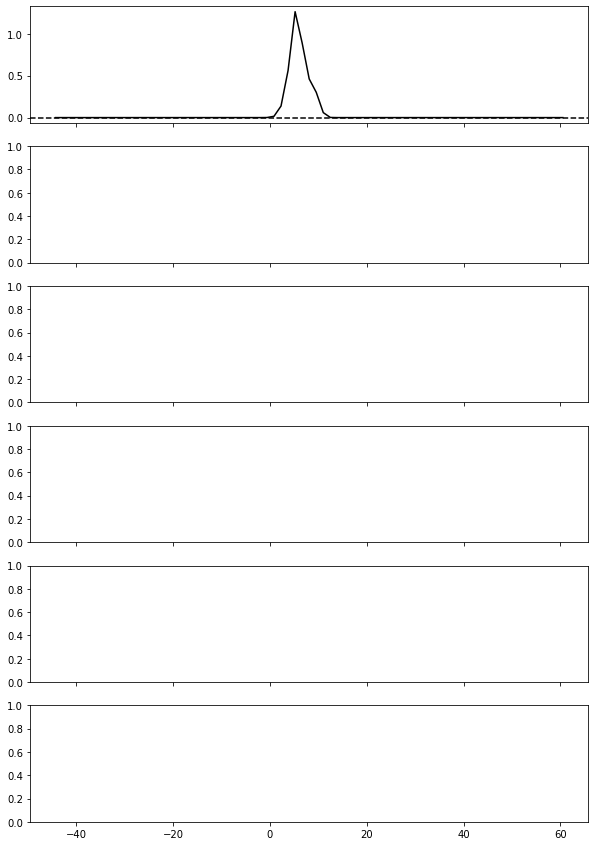

In [43]:
# Plot the data:
fig, axs = plt.subplots(6, figsize=(10, 15), sharex='all')

# Plot the OH:
axs[0].plot(velnoh-25, dn_OH_tot/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)
axs[0].set_xlim([31, 100])
axs[0].legend(loc='best')

axs[1].step(VelSof, (TaSof/8), 'k', label='OH 2.5 THz')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[1].legend(loc='best')

axs[2].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz')
axs[2].plot(vel67, y_fit67, color='r', ls='dashed')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[2].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[2].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[1].set_ylim([-0.08, 0.05])
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz')
axs[3].plot(vel65, y_fit65, color='r', ls='dashed')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[3].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[3].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[2].set_ylim([-0.08, 0.05])
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[3].legend(loc='best')

axs[4].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz')
axs[4].plot(vel12, y_fit12, color='r', ls='dashed')
axs[4].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[4].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[4].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
#axs[3].set_ylim([-0.08, 0.05])
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

axs[5].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz')
axs[5].plot(vel20, y_fit20, color='r', ls='dashed')
axs[5].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[5].axvline(out.params['cen2_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[5].axvline(out.params['cen3_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
#axs[4].set_ylim([-0.08, 0.05])
axs[5].axhline(0, color='k', ls='dashed')
axs[5].legend(loc='best')

plt.xlabel('Velocity (km/s)')
#fig.savefig("W49N_ThreeComponent.png", format='png')
axs[0].set_title('W49N')

In [ ]:
EWsofW49C1_rms

In [ ]:
igood = np.where((VelSof >= 38) & (VelSof <= 42))
len(TaSof[igood])

In [ ]:
# Error in Sofia EW assuming the
EWsofW49C1_rms * np.sqrt(28) *0.145

In [ ]:
# For default bounds, add upper and lower on other calls:

### Componment 1

# RMS calculation:
EWsofW49C1_rms = rms(VelSof, TaSof/8, upper = 80, lower = 75)
EW67W49C1_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 90, lower = 70)
EW65W49C1_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 90, lower = 70)
EW12W49C1_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 90, lower = 70)
EW20W49C1_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 90, lower = 70)

#EWSofiaW51 = ew(VelSof, TaSof/8, upper = 42, lower = 38)
EWsofW49C1 = ew(VelSof, TaSof/8, EWsofW49C1_rms, upper = 42, lower = 38)
EW67W49C1 = ew(vel67, (Ta67-Tc67)/Tc67, EW67W49C1_rms, upper = 42, lower = 38)
EW65W49C1 = ew(vel65, (Ta65-Tc65)/Tc65, EW65W49C1_rms, upper = 42, lower = 38)
EW12W49C1 = ew(vel12, (Ta12-Tc12)/Tc12, EW12W49C1_rms, upper = 42, lower = 38)
EW20W49C1 = ew(vel20, (Ta20-Tc20)/Tc20, EW20W49C1_rms, upper = 42, lower = 38)

print("Central Velocity:" + str(out.params['cen1_1'].value) + ' sigma= ' + str(out.params['sig1_1'].value))
print(EWsofW49C1)
print(EW67W49C1)
print(EW65W49C1)
print(EW12W49C1)
print(EW20W49C1)

# Excitation Temperatures:
print("\n")
ex67w49C1 = ex(EW67W49C1[0], columnDensity1, 67)
ex65w49C1 = ex(EW65W49C1[0], columnDensity1, 65)
ex12w49C1 = ex(EW12W49C1[0], columnDensity1, 12)
ex20w49C1 = ex(EW20W49C1[0], columnDensity1, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67w49C1_err = np.abs(ex67w49C1) * np.sqrt((EW67W49C1[1]/EW67W49C1[0])**2 + (0.05e14/columnDensity1)**2)
ex65w49C1_err = np.abs(ex65w49C1) * np.sqrt((EW65W49C1[1]/EW65W49C1[0])**2 + (0.05e14/columnDensity1)**2)
ex12w49C1_err = np.abs(ex12w49C1) * np.sqrt((EW12W49C1[1]/EW12W49C1[0])**2 + (0.05e14/columnDensity1)**2)
ex20w49C1_err = np.abs(ex20w49C1) * np.sqrt((EW20W49C1[1]/EW20W49C1[0])**2 + (0.05e14/columnDensity1)**2)

print("Tex for 1667 is: " + str(-ex67w49C1) + " +/- " + str(ex67w49C1_err))
print("Tex for 1665 is: " + str(-ex65w49C1) + " +/- " + str(ex65w49C1_err))
print("Tex for 1612 is: " + str(-ex12w49C1) + " +/- " + str(ex12w49C1_err))
print("Tex for 1720 is: " + str(-ex20w49C1) + " +/- " + str(ex20w49C1_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12w49C1/ex67w49C1)
print(ex65w49C1/ex67w49C1)
print(ex67w49C1/ex67w49C1)
print(ex20w49C1/ex67w49C1)
print("\n")

### Componment 2

# RMS calculation:
EWsofW49C2_rms = rms(VelSof, TaSof/8, upper = 80, lower = 75)
EW67W49C2_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 90, lower = 70)
EW65W49C2_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 90, lower = 70)
EW12W49C2_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 90, lower = 70)
EW20W49C2_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 90, lower = 70)

#EWSofiaW51 = ew(VelSof, TaSof/8, upper = 60, lower = 56)
EWsofW49C2 = ew(VelSof, TaSof/8, EWsofW49C2_rms, upper = 60, lower = 58)
EW67W49C2 = ew(vel67, (Ta67-Tc67)/Tc67, EW67W49C2_rms, upper = 60, lower = 58)
EW65W49C2 = ew(vel65, (Ta65-Tc65)/Tc65, EW65W49C2_rms, upper = 60, lower = 58)
EW12W49C2 = ew(vel12, (Ta12-Tc12)/Tc12, EW12W49C2_rms, upper = 60, lower = 58)
EW20W49C2 = ew(vel20, (Ta20-Tc20)/Tc20, EW20W49C2_rms, upper = 60, lower = 58)

print("Central Velocity:" + str(out.params['cen2_1'].value) + ' sigma= ' + str(out.params['sig2_1'].value))
print(EWsofW49C2)
print(EW67W49C2)
print(EW65W49C2)
print(EW12W49C2)
print(EW20W49C2)

# Excitation Temperatures:
print("\n")
ex67w49C2 = ex(EW67W49C2[0], columnDensity2, 67)
ex65w49C2 = ex(EW65W49C2[0], columnDensity2, 65)
ex12w49C2 = ex(EW12W49C2[0], columnDensity2, 12)
ex20w49C2 = ex(EW20W49C2[0], columnDensity2, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67w49C2_err = np.abs(ex67w49C2) * np.sqrt((EW67W49C2[1]/EW67W49C2[0])**2 + (0.05e14/columnDensity2)**2)
ex65w49C2_err = np.abs(ex65w49C2) * np.sqrt((EW65W49C2[1]/EW65W49C2[0])**2 + (0.05e14/columnDensity2)**2)
ex12w49C2_err = np.abs(ex12w49C2) * np.sqrt((EW12W49C2[1]/EW12W49C2[0])**2 + (0.05e14/columnDensity2)**2)
ex20w49C2_err = np.abs(ex20w49C2) * np.sqrt((EW20W49C2[1]/EW20W49C2[0])**2 + (0.05e14/columnDensity2)**2)

print("Tex for 1667 is: " + str(-ex67w49C2) + " +/- " + str(ex67w49C2_err))
print("Tex for 1665 is: " + str(-ex65w49C2) + " +/- " + str(ex65w49C2_err))
print("Tex for 1612 is: " + str(-ex12w49C2) + " +/- " + str(ex12w49C2_err))
print("Tex for 1720 is: " + str(-ex20w49C2) + " +/- " + str(ex20w49C2_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12w49C2/ex67w49C2)
print(ex65w49C2/ex67w49C2)
print(ex67w49C2/ex67w49C2)
print(ex20w49C2/ex67w49C2)
print("\n")

### Componment 3

# RMS calculation:
EWsofW49C3_rms = rms(VelSof, TaSof/8, upper = 80, lower = 75)
EW67W49C3_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 90, lower = 70)
EW65W49C3_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 90, lower = 70)
EW12W49C3_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 90, lower = 70)
EW20W49C3_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 90, lower = 70)

#EWSofiaW51 = ew(VelSof, TaSof/8, upper = 63, lower = 60)
EWsofW49C3 = ew(VelSof, TaSof/8, EWsofW49C3_rms, upper = 62, lower = 60)
EW67W49C3 = ew(vel67, (Ta67-Tc67)/Tc67, EW67W49C3_rms, upper = 62, lower = 60)
EW65W49C3 = ew(vel65, (Ta65-Tc65)/Tc65, EW65W49C3_rms, upper = 62, lower = 60)
EW12W49C3 = ew(vel12, (Ta12-Tc12)/Tc12, EW12W49C3_rms, upper = 62, lower = 60)
EW20W49C3 = ew(vel20, (Ta20-Tc20)/Tc20, EW20W49C3_rms, upper = 62, lower = 60)

print("Central Velocity:" + str(out.params['cen3_1'].value) + ' sigma= ' + str(out.params['sig3_1'].value))
print(EWsofW49C3)
print(EW67W49C3)
print(EW65W49C3)
print(EW12W49C3)
print(EW20W49C3)

# Excitation Temperatures:
print("\n")
ex67w49C3 = ex(EW67W49C3[0], columnDensity3, 67)
ex65w49C3 = ex(EW65W49C3[0], columnDensity3, 65)
ex12w49C3 = ex(EW12W49C3[0], columnDensity3, 12)
ex20w49C3 = ex(EW20W49C3[0], columnDensity3, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67w49C3_err = np.abs(ex67w49C3) * np.sqrt((EW67W49C3[1]/EW67W49C3[0])**2 + (0.05e13/columnDensity3)**2)
ex65w49C3_err = np.abs(ex65w49C3) * np.sqrt((EW65W49C3[1]/EW65W49C3[0])**2 + (0.05e13/columnDensity3)**2)
ex12w49C3_err = np.abs(ex12w49C3) * np.sqrt((EW12W49C3[1]/EW12W49C3[0])**2 + (0.05e13/columnDensity3)**2)
ex20w49C3_err = np.abs(ex20w49C3) * np.sqrt((EW20W49C3[1]/EW20W49C3[0])**2 + (0.05e13/columnDensity3)**2)

print("Tex for 1667 is: " + str(-ex67w49C3) + " +/- " + str(ex67w49C3_err))
print("Tex for 1665 is: " + str(-ex65w49C3) + " +/- " + str(ex65w49C3_err))
print("Tex for 1612 is: " + str(-ex12w49C3) + " +/- " + str(ex12w49C3_err))
print("Tex for 1720 is: " + str(-ex20w49C3) + " +/- " + str(ex20w49C3_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12w49C3/ex67w49C3)
print(ex65w49C3/ex67w49C3)
print(ex67w49C3/ex67w49C3)
print(ex20w49C3/ex67w49C3)

In [ ]:
#Add component 1 to Table:
dataTable.add_row(("W49", out.params['cen1_1'].value, out.params['sig1_1'].value, 
                  -ex12w49C1, ex12w49C1_err,
                  -ex65w49C1, ex65w49C1_err,
                  -ex67w49C1, ex67w49C1_err,
                  -ex20w49C1, ex20w49C1_err,
                  EWsofW49C1[0], EWsofW49C1[1],
                  EW12W49C1[0], EW12W49C1[1],
                  EW65W49C1[0], EW65W49C1[1],
                  EW67W49C1[0], EW67W49C1[1],
                  EW20W49C1[0], EW20W49C1[1],
                  columnDensity1
                 ))

#Add component 2 to Table:
dataTable.add_row(("W49", out.params['cen2_1'].value, out.params['sig2_1'].value, 
                  -ex12w49C2, ex12w49C2_err,
                  -ex65w49C2, ex65w49C2_err,
                  -ex67w49C2, ex67w49C2_err,
                  -ex20w49C2, ex20w49C2_err,
                  EWsofW49C2[0], EWsofW49C2[1],
                  EW12W49C2[0], EW12W49C2[1],
                  EW65W49C2[0], EW65W49C2[1],
                  EW67W49C2[0], EW67W49C2[1],
                  EW20W49C2[0], EW20W49C2[1],
                  columnDensity2
                 ))

#Add component 3 to Table:
dataTable.add_row(("W49", out.params['cen3_1'].value, out.params['sig3_1'].value, 
                  -ex12w49C3, ex12w49C3_err,
                  -ex65w49C3, ex65w49C3_err,
                  -ex67w49C3, ex67w49C3_err,
                  -ex20w49C3, ex20w49C3_err,
                  EWsofW49C3[0], EWsofW49C3[1],
                  EW12W49C3[0], EW12W49C3[1],
                  EW65W49C3[0], EW65W49C3[1],
                  EW67W49C3[0], EW67W49C3[1],
                  EW20W49C3[0], EW20W49C3[1],
                  columnDensity3
                 ))

In [ ]:
dataTable

### Plotting W3IRS5:

In [60]:
# Load OH spectra toward W3 IRS5:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/W3IRS5_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
w3noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_W3IRS5.csv')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -30) & (VelSof <= 20))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W3 IRS5:
oh671 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=808)
oh651 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=811, data_end=1610)
oh121 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=1613, data_end=2412)
oh201 = ascii.read("ShallowClean/w3irs5/w3irs5-3.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=2415, data_end=3214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']
velnoh = w3noh['v_lsr']-39
noh = w3noh['N(OH)']


# Choose velocity range.
igood67 = np.where((vel67 >= -30) & (vel67 <= 20))
igood65 = np.where((vel65 >= -30) & (vel65 <= 20))
igood12 = np.where((vel12 >= -30) & (vel12 <= 20))
igood20 = np.where((vel20 >= -30) & (vel20 <= 20))
igoodnoh = np.where((velnoh >= -30) & (velnoh <= 20))

# Choose a continuum.
igood67c = np.where((vel67 >= -130) & (vel67 <= -70))
igood65c = np.where((vel65 >= -130) & (vel65 <= -70))
igood12c = np.where((vel12 >= -130) & (vel12 <= -70))
igood20c = np.where((vel20 >= -130) & (vel20 <= -70))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]
velnoh = velnoh[igoodnoh]
noh = noh[igoodnoh]

# What is the column density?
delta = abs(velnoh[1]-velnoh[0])

# Component 1:
igoodnoh = np.where((velnoh >= -23) & (velnoh <= -18))
columnDensity = np.sum(noh[igoodnoh])*delta

In [61]:
delta

0.4947487100000032

In [62]:
columnDensity

74655229619635.81

In [63]:
# This is different from Arshia's paper number. and I checked the google drive and calculated the column density
# from that google sheet and it was 0.75e13 so I am confused!
# I will use this however. The resulting ex is okay.

In [64]:
columnDensity*u.cm**2

<Quantity 7.46552296e+13 cm2>

In [65]:
#Arshia's value is, a little different, would be compatible if not using a delta v for the integral and instead using a sum.
# 7.5e13

In [66]:
data = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
data = np.array(data)

In [67]:
# Perform a Gaussian fit around the center velocity of the identified clouds:

# How many Gaussians are we going to use?
def gauss_dataset(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    #amp2 = params[f'amp2_{i+1}']
    #cen2 = params[f'cen2_{i+1}']
    #sig2 = params[f'sig2_{i+1}']
    #amp3 = params[f'amp3_{i+1}']
    #cen3 = params[f'cen3_{i+1}']
    #sig3 = params[f'sig3_{i+1}']
    
    return gauss(x, amp1, cen1, sig1)# + gauss(x, amp2, cen2, sig2) + gauss(x, amp3, cen3, sig3)# + gauss(x, amp4, cen4, sig4) + gauss(x, amp5, cen5, sig5)

# Create the fitters:
fit_params = Parameters()
for iy, y in enumerate(data):
    # First Gaussian
    fit_params.add(f'amp1_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen1_{iy+1}', value=-22, min=-25, max=-20)
    fit_params.add(f'sig1_{iy+1}', value=0.5, min=0.01, max=2.0)
    # Second Gaussian
    #fit_params.add(f'amp2_{iy+1}', value=0, min=-5, max=5)
    #fit_params.add(f'cen2_{iy+1}', value=60, min=50, max=69)
    #fit_params.add(f'sig2_{iy+1}', value=0.5, min=0.01, max=2.0)
     # Third Gaussian
    #fit_params.add(f'amp3_{iy+1}', value=0, min=-5, max=5)
    #fit_params.add(f'cen3_{iy+1}', value=57, min=50, max=69)
    #fit_params.add(f'sig3_{iy+1}', value=0.5, min=0.01, max=2.0)

# Set all FWHM, center to be the same:
for iy in (2,3,4):
    # First Gaussian
    fit_params[f'sig1_{iy}'].expr = 'sig1_1'
    fit_params[f'cen1_{iy}'].expr = 'cen1_1'
    # Second Gaussian
    #fit_params[f'sig2_{iy}'].expr = 'sig2_1'
    #fit_params[f'cen2_{iy}'].expr = 'cen2_1'
    # Thid Gaussian
    #fit_params[f'sig3_{iy}'].expr = 'sig3_1'
    #fit_params[f'cen3_{iy}'].expr = 'cen3_1'

In [68]:
# Create two data arrays, one for VLA and one for Sofia:
dataVLA = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
dataVLA = np.array(dataVLA)

dataSof = [(TaSof/7.8)]
dataSof = np.array(dataSof)

In [69]:
# For multiple components:

# Number of gas components:
n = 1

# Add in intitial guesses
p0 = [-21]

# Instantiate fit parameters:
fit_params = Parameters()

# Set parameters:
makeVLA(n, dataVLA, fit_params, p0)
makeSOFIA(n, dataSof, fit_params, p0)

In [70]:
# Perform a fit:
#out = minimize(objective, fit_params, args=(vel67, data))
#report_fit(out.params)

out = minimize(fcn=objective_n, params=fit_params, args=(n, vel67, VelSof, dataVLA, dataSof))
report_fit(out)

ValueError: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.

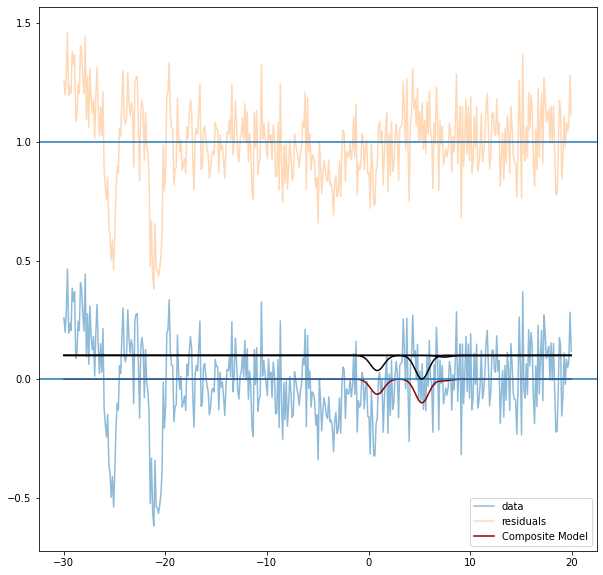

In [71]:
# We were able to fit 2 components (6 gaussians)!
fig = plt.figure(figsize=(10,10))

plt.plot(VelSof, TaSof/7.8, alpha=0.5, label='data')
plt.plot(VelSof, (TaSof/7.8-gauss_dataset_sof_n(n=n, params=out.params, x=VelSof)+1), alpha=0.3, label='residuals')
plt.plot(VelSof, gauss_dataset_sof_n(n=n, params=out.params, x=VelSof), color='darkred', label='Composite Model')
plt.axhline(1)
plt.axhline(0)

for i in range(n):
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof)+0.1, color='black')
    plt.plot(VelSof, gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof)+0.1, color='black')

#plt.axvline(out.params['cen5_1_0'].value)
#plt.axvline(out.params['cen5_1_1'].value)
#plt.axvline(out.params['cen5_1_2'].value)

plt.legend()

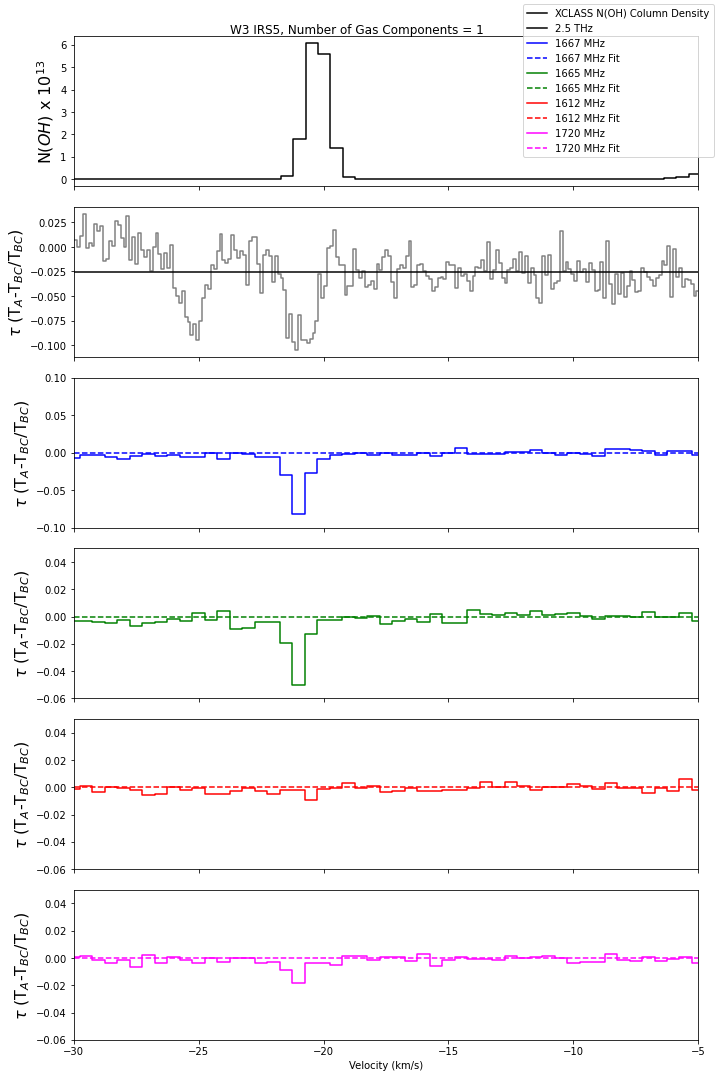

In [72]:
# Set the x axis:
x = vel67

# Get the best fit for plotting:
y_fitsof = gauss_dataset_sof_n(out.params, n, VelSof)
y_fit67 = gauss_dataset_n(out.params, n, 0, x)
y_fit65 = gauss_dataset_n(out.params, n, 1, x)
y_fit12 = gauss_dataset_n(out.params, n, 2, x)
y_fit20 = gauss_dataset_n(out.params, n, 3, x)

# Plotting the Data and Models:
fig, axs = plt.subplots(6, figsize=(10,15), sharex='all')
fig.suptitle('W3 IRS5, Number of Gas Components = ' + str(n))

axs[0].step(velnoh-delta, noh/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)

axs[1].step(VelSof, (dataSof[0,:]-0.2)/7.8, color='BLACK', alpha=0.5)
axs[1].step(VelSof, (y_fitsof-0.2)/7.8, color='Black', label='2.5 THz')
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)

#for i in range(n):
#    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 5, i, x=VelSof)-0.2)/7.8, color='black', ls='dashed')
#    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 6, i, x=VelSof)-0.2)/7.8, color='black', ls='dashed')
#    axs[1].plot(VelSof, (gauss_dataset_single_n(out.params, 0, 7, i, x=VelSof)-0.2)/7.8, color='black', ls='dashed')

axs[2].step(x, dataVLA[0,:], color='BLUE', label='1667 MHz', where='mid')
axs[2].plot(x, y_fit67, color='BLUE', label='1667 MHz Fit', ls='dashed')
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].set_ylim(-0.1, 0.1)
#for i in range(n):
#    axs[2].step(x, gauss_dataset_n(out.params, i+1, 0, x)+0.3, color='BLUE', ls='-.', alpha=0.5, where='mid')

axs[3].step(x, dataVLA[1,:], color='GREEN', label='1665 MHz', where='mid')
axs[3].plot(x, y_fit65, color='GREEN', label='1665 MHz Fit', ls='dashed')
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[3].set_ylim(-0.06, 0.05)
#for i in range(n):
#    axs[3].step(x, gauss_dataset_n(out.params, i+1, 1, x)+0.17, alpha=0.5, color='GREEN', ls='-.', where='mid')

axs[4].step(x, dataVLA[2,:], color='RED', label='1612 MHz', where='mid')
axs[4].plot(x, y_fit12, color='RED', label='1612 MHz Fit', ls='dashed')
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].set_ylim(-0.06, 0.05)
#for i in range(n):
#    axs[4].step(x, gauss_dataset_n(out.params, i+1, 2, x)+0.1, color='RED', ls='-.',  alpha=0.5, where='mid')

axs[5].step(x, dataVLA[3,:], color='MAGENTA', label='1720 MHz', where='mid')
axs[5].plot(x, y_fit20, color='MAGENTA', label='1720 MHz Fit', ls='dashed')
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[5].set_ylim(-0.06, 0.05)
#for i in range(n):
#    axs[5].step(x, gauss_dataset_n(out.params, i+1, 3, x)+0.045, color='MAGENTA', alpha=0.5, ls='-.', where='mid')

#plt.axvline(out.params['cen1_1_0'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_1'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_2'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_3'].value, alpha=0.5, ls='dashed')
#plt.axvline(out.params['cen1_1_4'].value, alpha=0.5, ls='dashed')

plt.xlim([-30, -5])
plt.xlabel('Velocity (km/s)')
fig.legend(loc='upper right')
fig.tight_layout()
plt.savefig('W3IRS5_n=1.pdf', format='pdf')

In [ ]:
plt.plot(velnoh, noh)

Text(0.5, 1.0, 'W3 IRS5')

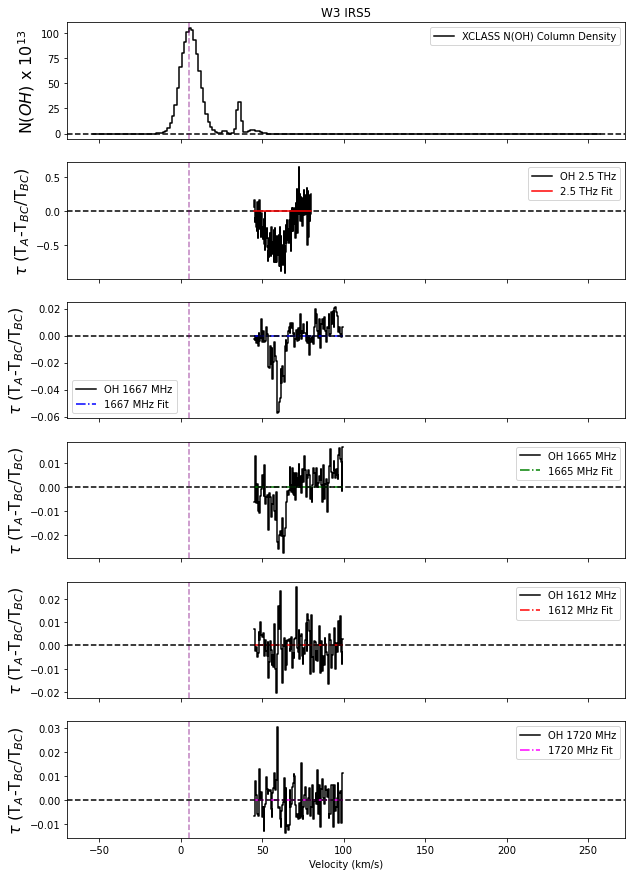

In [59]:
# Continuum Temperature for W3 IRS5 is 7.8K

# Plot the data:
fig, axs = plt.subplots(6, figsize=(10, 15), sharex='all')

# Plot the OH:
axs[0].step(velnoh-delta, noh/1e13, 'k', label='XCLASS N(OH) Column Density', where='mid')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)
axs[0].legend(loc='best')

axs[1].step(VelSof, (TaSof)/7.8, 'k', label='OH 2.5 THz', where='mid')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].step(VelSof, y_fitsof, color='RED', label='2.5 THz Fit', where='mid')
axs[1].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[1].legend(loc='best')

axs[2].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz', where='mid')
#axs[2].plot(vel67, y_fit67, color='r', ls='dashed')
axs[2].step(x, gauss_dataset_n(out.params, 1, 0, x), color='BLUE', ls='-.', where='mid', label='1667 MHz Fit')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
#axs[2].set_ylim([-0.08, 0.01])
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz', where='mid')
#axs[3].plot(vel65, y_fit65, color='r', ls='dashed')
axs[3].step(x, gauss_dataset_n(out.params, 1, 1, x), color='GREEN', ls='-.', label='1665 MHz Fit', where='mid')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
#axs[3].set_ylim([-0.08, 0.01])
axs[3].legend(loc='best')

axs[4].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz', where='mid')
#axs[4].plot(vel12, y_fit12, color='r', ls='dashed')
axs[4].step(x, gauss_dataset_n(out.params, 1, 2, x), color='RED', ls='-.', label='1612 MHz Fit', where='mid')
axs[4].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].axhline(0, color='k', ls='dashed')
#axs[4].set_ylim([-0.08, 0.01])
axs[4].legend(loc='best')

axs[5].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz', where='mid')
#axs[5].plot(vel20, y_fit20, color='r', ls='dashed')
axs[5].step(x, gauss_dataset_n(out.params, 1, 3, x), color='MAGENTA', ls='-.', label='1720 MHz Fit', where='mid')
axs[5].axvline(out.params['cen1_1_0'].value, color='purple', ls='dashed', alpha=0.5)
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[5].axhline(0, color='k', ls='dashed')
#axs[5].set_ylim([-0.08, 0.01])
axs[5].legend(loc='best')

plt.xlabel('Velocity (km/s)')
#fig.savefig("W49N_OneComponent.png", format='png')
axs[0].set_title('W3 IRS5')

In [ ]:
igood = np.where((vel67 >= -10) & (vel67 <= 20))
len(TaSof[igood])

In [ ]:
out.params

In [ ]:
# For default bounds, add upper and lower on other calls:

# RMS calculation:
EWsofW3_rms = rms(VelSof, TaSof/7.8, upper = 20, lower = 5)
EW67W3_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 20, lower = -10)
EW65W3_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 20, lower = -10)
EW12W3_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 20, lower = -10)
EW20W3_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 20, lower = -10)

#EWSofiaW51 = ew(VelSof, TaSof/8, upper = -20, lower = -23
EWsofW3 = ew(VelSof, TaSof/7.8, EWsofW3_rms, upper = out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value, lower = out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value)
EW67W3 = ew(vel67, (Ta67-Tc67)/Tc67, EW67W3_rms, upper = out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value, lower = out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value)
EW65W3 = ew(vel65, (Ta65-Tc65)/Tc65, EW65W3_rms,  upper = out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value, lower = out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value)
EW12W3 = ew(vel12, (Ta12-Tc12)/Tc12, EW12W3_rms, upper = out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value, lower = out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value)
EW20W3 = ew(vel20, (Ta20-Tc20)/Tc20, EW20W3_rms, upper = out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value, lower = out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value)

print("Central Velocity:" + str(out.params['cen1_1_0'].value))
print("The EW and error of 2.5 THz between " +str(out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value) +" and "+str(out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value) + " is:" + str(EWsofW3))
print("The EW and error of 1667 MHz between " +str(out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value) +" and "+str(out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value) + " is:" + str(EW67W3))
print("The EW and error of 1665 MHz between " +str(out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value) +" and "+str(out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value) + " is:" + str(EW65W3))
print("The EW and error of 1612 MHz between " +str(out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value) +" and "+str(out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value) + " is:" + str(EW12W3))
print("The EW and error of 1720 MHz between " +str(out.params['cen1_1_0'].value-3*out.params['sig1_1_0'].value) +" and "+str(out.params['cen1_1_0'].value+3*out.params['sig1_1_0'].value) + " is:" + str(EW20W3))

print("\n")
# Excitation Temperatures:
print("The column density from the HyGal XCLASS fits is: " + str(columnDensity))
print("\n")
ex67w3 = ex(EW67W3[0], columnDensity, 67)
ex65w3 = ex(EW65W3[0], columnDensity, 65)
ex12w3 = ex(EW12W3[0], columnDensity, 12)
ex20w3 = ex(EW20W3[0], columnDensity, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67w3_err = np.abs(ex67w3) * np.sqrt((EW67W3[1]/EW67W3[0])**2 + (0.05/0.75)**2)
ex65w3_err = np.abs(ex65w3) * np.sqrt((EW65W3[1]/EW65W3[0])**2 + (0.05/0.75)**2)
ex12w3_err = np.abs(ex12w3) * np.sqrt((EW12W3[1]/EW12W3[0])**2 + (0.05/0.75)**2)
ex20w3_err = np.abs(ex20w3) * np.sqrt((EW20W3[1]/EW20W3[0])**2 + (0.05/0.75)**2)

print("Tex for 1667 is: " + str(-ex67w3) + " +/- " + str(ex67w3_err))
print("Tex for 1665 is: " + str(-ex65w3) + " +/- " + str(ex65w3_err))
print("Tex for 1612 is: " + str(-ex12w3) + " +/- " + str(ex12w3_err))
print("Tex for 1720 is: " + str(-ex20w3) + " +/- " + str(ex20w3_err))


# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12w3/ex67w3)
print(ex65w3/ex67w3)
print(ex67w3/ex67w3)
print(ex20w3/ex67w3)

In [ ]:
print(np.abs(EW67W3[0])/EW67W3[1])
print(np.abs(EW65W3[0])/EW65W3[1])
print(np.abs(EW12W3[0])/EW12W3[1])
print(np.abs(EW20W3[0])/EW20W3[1])

In [ ]:
#Add component 1 to Table:
dataTable.add_row(("W3 IRS5", out.params['cen1_1_0'].value, out.params['sig1_1_0'].value, 
                  -ex12w3, ex12w3_err,
                  -ex65w3, ex65w3_err,
                  -ex67w3, ex67w3_err,
                  -ex20w3, ex20w3_err,
                  EWsofW3[0], EWsofW3[1],
                  EW12W3[0], EW12W3[1],
                  EW65W3[0], EW65W3[1],
                  EW67W3[0], EW67W3[1],
                  EW20W3[0], EW20W3[1],
                  columnDensity
                 ))

In [ ]:
dataTable

### Now let's plot G34 and fit it:

In [74]:
# Load OH spectra toward W51:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/G34P_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
g34noh = ascii.read('Column_density_distributions/Column_density_distributions/coldens_OH_G34P26.csv')
g34noh_real = ascii.read('OH_data_deltav_0p1/AG34P2_OH.spec')
ohsof_ogres = ascii.read('OH_data_deltav_0p1/G34P26_OH_2Pi32_velo.txt')

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -10) & (VelSof <= 40))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/G34/G34-1.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']
velnoh = g34noh['col1']
noh = g34noh['col2']

# Choose velocity range.
igood67 = np.where((vel67 >= -40) & (vel67 <= 40))
igood65 = np.where((vel65 >= -40) & (vel65 <= 40))
igood12 = np.where((vel12 >= -40) & (vel12 <= 40))
igood20 = np.where((vel20 >= -40) & (vel20 <= 40))

# Choose a continuum.
igood67c = np.where((vel67 >= -40) & (vel67 <= -20))
igood65c = np.where((vel65 >= -40) & (vel65 <= -20))
igood12c = np.where((vel12 >= -40) & (vel12 <= -20))
igood20c = np.where((vel20 >= -40) & (vel20 <= -20))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]

g34noh = ascii.read('XCLASS_fits/XCLASS_fits/OH_G34P26.molfit')

Area_OH = g34noh['col1']

mu_OH = g34noh['col3']

sigma_OH = g34noh['col2']/2.3

A_OH = Area_OH/(g34noh['col2']*const)

dn_OH_tot = 0

for i in range(0, len(mu_OH)):
   dn_OH_tot = dn_OH_tot + gauss(ohsof_ogres['col1'], A_OH[i], mu_OH[i], sigma_OH[i])

# What is the column density?
delta = abs(ohsof_ogres['col1'][1]-ohsof_ogres['col1'][0])

# Component 1:
igoodnoh = np.where((ohsof_ogres['col1']-20 >= 8) & (ohsof_ogres['col1']-20 <= 15))
columnDensity1 = np.sum(dn_OH_tot[igoodnoh])*delta

# Component 2:
igoodnoh = np.where((ohsof_ogres['col1']-20 >= 25) & (ohsof_ogres['col1']-20 <= 32))
columnDensity2 = np.sum(dn_OH_tot[igoodnoh])*delta

In [75]:
columnDensity1*u.cm**2

<Quantity 1.18414383e+14 cm2>

In [76]:
columnDensity2*u.cm**2

<Quantity 7.0350138e+13 cm2>

In [77]:
# We solved a problem by breaking it into parts--this new file is the column density distro. for G34 with the correct velo offset.
#import csv

#with open('coldens_OH_G34p26.csv', 'w') as f:
#    writer = csv.writer(f, delimiter=',')
#    writer.writerows(zip(ohsof_ogres['col1']-20, dn_OH_tot))

(-10.0, 40.0)

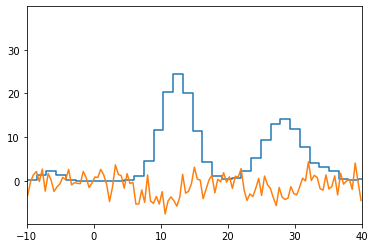

In [78]:
plt.step(ohsof_ogres['col1']-20, dn_OH_tot/0.1e13)
#plt.step(velnoh, noh/0.1e13)
plt.plot(VelSof[::3], (TaSof[::3]))
plt.xlim([-10, 40])

In [79]:
Tc67

2450.264404297

In [ ]:
data = [((Ta67-Tc67)/Tc67).value, ((Ta65-Tc65)/Tc65).value, ((Ta12-Tc12)/Tc12).value, ((Ta20-Tc20)/Tc20).value]
data = np.array(data)

In [ ]:
# Perform a Gaussian fit around the center velocity of the identified clouds:

# How many Gaussians are we going to use?
def gauss_dataset(params, i, x):
    """Calculate Gaussian lineshape from parameters for data set."""
    amp1 = params[f'amp1_{i+1}']
    cen1 = params[f'cen1_{i+1}']
    sig1 = params[f'sig1_{i+1}']
    amp2 = params[f'amp2_{i+1}']
    cen2 = params[f'cen2_{i+1}']
    sig2 = params[f'sig2_{i+1}']
    #amp3 = params[f'amp3_{i+1}']
    #cen3 = params[f'cen3_{i+1}']
    #sig3 = params[f'sig3_{i+1}']
    
    return gauss(x, amp1, cen1, sig1) + gauss(x, amp2, cen2, sig2)# + gauss(x, amp3, cen3, sig3)# + gauss(x, amp4, cen4, sig4) + gauss(x, amp5, cen5, sig5)

# Create the fitters:
fit_params = Parameters()
for iy, y in enumerate(data):
    # First Gaussian
    fit_params.add(f'amp1_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen1_{iy+1}', value=12, min=10, max=15)
    fit_params.add(f'sig1_{iy+1}', value=0.5, min=0.01, max=2.0)
    # Second Gaussian
    fit_params.add(f'amp2_{iy+1}', value=0, min=-5, max=5)
    fit_params.add(f'cen2_{iy+1}', value=27, min=23, max=31)
    fit_params.add(f'sig2_{iy+1}', value=0.5, min=0.01, max=2.0)
     # Third Gaussian
    #fit_params.add(f'amp3_{iy+1}', value=0, min=-5, max=5)
    #fit_params.add(f'cen3_{iy+1}', value=57, min=50, max=69)
    #fit_params.add(f'sig3_{iy+1}', value=0.5, min=0.01, max=2.0)

# Set all FWHM, center to be the same:
for iy in (2,3,4):
    # First Gaussian
    fit_params[f'sig1_{iy}'].expr = 'sig1_1'
    fit_params[f'cen1_{iy}'].expr = 'cen1_1'
    # Second Gaussian
    fit_params[f'sig2_{iy}'].expr = 'sig2_1'
    fit_params[f'cen2_{iy}'].expr = 'cen2_1'
    # Thid Gaussian
    #fit_params[f'sig3_{iy}'].expr = 'sig3_1'
    #fit_params[f'cen3_{iy}'].expr = 'cen3_1'

In [ ]:
# Perform a fit:
out = minimize(objective, fit_params, args=(vel67, data))
report_fit(out.params)

In [ ]:
plt.figure()
for i in range(4):
    y_fit = gauss_dataset(out.params, i, vel67)
    plt.step(vel67, data[i, :], 'k', vel67, y_fit, '-')
    
# Get the best fit for plotting:
y_fit67 = gauss_dataset(out.params, 0, vel67)
y_fit65 = gauss_dataset(out.params, 1, vel67)
y_fit12 = gauss_dataset(out.params, 2, vel67)
y_fit20 = gauss_dataset(out.params, 3, vel67)

KeyError: 'cen1_1'

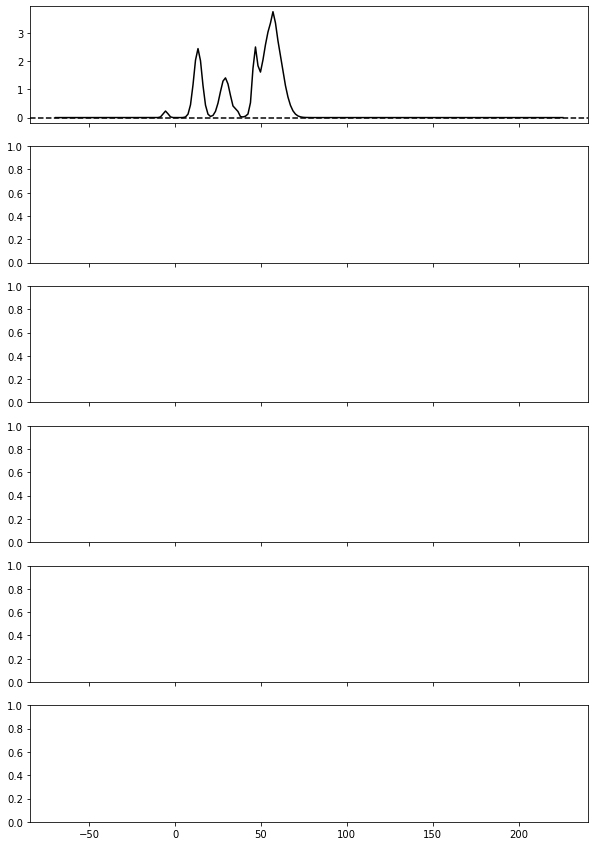

In [80]:
# Continuum Temperature for W3 IRS5 is 8.2K

# Plot the data:
fig, axs = plt.subplots(6, figsize=(10, 15), sharex='all')

# Plot the OH:
#axs[0].step(g34noh_real['col1'], (g34noh_real['col2']+8.2)/8.2, color='red')

axs[0].plot(velnoh-20, dn_OH_tot/1e13, 'k', label='XCLASS N(OH) Column Density')
axs[0].axhline(0, color='k', ls='dashed')
axs[0].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[0].set_xlim([-40, 40])
axs[0].set_ylabel(r'N$(OH)$ x 10$^{13}$', size=16)
axs[0].legend(loc='best')

axs[1].step(VelSof, ((TaSof)/8.2), 'k', label='OH 2.5 THz')
axs[1].axhline(0, color='k', ls='dashed')
axs[1].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[1].set_ylabel(r'(T$_{A}$/T$_{BC}$)', size=16)
axs[1].legend(loc='best')

axs[2].step(vel67, (Ta67-Tc67)/Tc67, 'k', label='OH 1667 MHz')
axs[2].plot(vel67, y_fit67, color='r', ls='dashed')
axs[2].axhline(0, color='k', ls='dashed')
axs[2].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[2].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[2].legend(loc='best')

axs[3].step(vel65, (Ta65-Tc65)/Tc65, 'k', label='OH 1665 MHz')
axs[3].plot(vel65, y_fit65, color='r', ls='dashed')
axs[3].axhline(0, color='k', ls='dashed')
axs[3].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[3].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[3].legend(loc='best')

axs[4].step(vel12, (Ta12-Tc12)/Tc12, 'k', label='OH 1612 MHz')
axs[4].plot(vel12, y_fit12, color='r', ls='dashed')
axs[4].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[4].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[4].axhline(0, color='k', ls='dashed')
axs[4].legend(loc='best')

axs[5].step(vel20, (Ta20-Tc20)/Tc20, 'k', label='OH 1720 MHz')
axs[5].plot(vel20, y_fit20, color='r', ls='dashed')
axs[5].axvline(out.params['cen1_1'].value, color='purple', ls='dashed', alpha=0.5)
axs[5].set_ylabel(r'$\tau$ (T$_{A}$-T$_{BC}$/T$_{BC}$)', size=16)
axs[5].axhline(0, color='k', ls='dashed')
axs[5].legend(loc='best')

plt.xlabel('Velocity (km/s)')
#fig.savefig("W49N_ThreeComponent.png", format='png')
axs[0].set_title('G34')

In [ ]:
# For default bounds, add upper and lower on other calls:

# RMS calculation:
EWsofg34C1_rms = rms(VelSof, TaSof/8.2, upper = 0, lower = -10)
EW67g34C1_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 5, lower = -40)
EW65g34C1_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 5, lower = -40)
EW12g34C1_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 5, lower = -40)
EW20g34C1_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 5, lower = -40)

# 11 km/s
EWsofg34C1 = ew(VelSof, TaSof/8.2, EWsofg34C1_rms, upper = 15, lower = 8)
EW67g34C1 = ew(vel67, (Ta67-Tc67)/Tc67, EW67g34C1_rms, upper = 15, lower = 8)
EW65g34C1 = ew(vel65, (Ta65-Tc65)/Tc65, EW65g34C1_rms, upper = 15, lower = 8)
EW12g34C1 = ew(vel12, (Ta12-Tc12)/Tc12, EW12g34C1_rms, upper = 15, lower = 8)
EW20g34C1 = ew(vel20, (Ta20-Tc20)/Tc20, EW20g34C1_rms, upper = 15, lower = 8)

print("Central Velocity:" + str(out.params[f'cen1_1'].value))
print(EWsofg34C1)
print(EW67g34C1)
print(EW65g34C1)
print(EW12g34C1)
print(EW20g34C1)

# Excitation Temperatures:
print("\n")
ex67g34C1 = ex(EW67g34C1[0], columnDensity1, 67)
ex65g34C1 = ex(EW65g34C1[0], columnDensity1, 65)
ex12g34C1 = ex(EW12g34C1[0], columnDensity1, 12)
ex20g34C1 = ex(EW20g34C1[0], columnDensity1, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67g34C1_err = np.abs(ex67g34C1) * np.sqrt((EW67g34C1[1]/EW67g34C1[0])**2)
ex65g34C1_err = np.abs(ex65g34C1) * np.sqrt((EW65g34C1[1]/EW65g34C1[0])**2)
ex12g34C1_err = np.abs(ex12g34C1) * np.sqrt((EW12g34C1[1]/EW12g34C1[0])**2)
ex20g34C1_err = np.abs(ex20g34C1) * np.sqrt((EW20g34C1[1]/EW20g34C1[0])**2)

print("Tex for 1667 is: " + str(-ex67g34C1) + " +/- " + str(ex67g34C1_err))
print("Tex for 1665 is: " + str(-ex65g34C1) + " +/- " + str(ex65g34C1_err))
print("Tex for 1612 is: " + str(-ex12g34C1) + " +/- " + str(ex12g34C1_err))
print("Tex for 1720 is: " + str(-ex20g34C1) + " +/- " + str(ex20g34C1_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12g34C1/ex67g34C1)
print(ex65g34C1/ex67g34C1)
print(ex67g34C1/ex67g34C1)
print(ex20g34C1/ex67g34C1)
print("\n")

# RMS calculation:
EWsofg34C2_rms = rms(VelSof, TaSof/8.2, upper = 0, lower = -10)
EW67g34C2_rms = rms(vel67, (Ta67-Tc67)/Tc67, upper = 5, lower = -40)
EW65g34C2_rms = rms(vel65, (Ta65-Tc65)/Tc65, upper = 5, lower = -40)
EW12g34C2_rms = rms(vel12, (Ta12-Tc12)/Tc12, upper = 5, lower = -40)
EW20g34C2_rms = rms(vel20, (Ta20-Tc20)/Tc20, upper = 5, lower = -40)

# 26 km/s
EWsofg34C2 = ew(VelSof, TaSof/8.2, EWsofg34C2_rms, upper = 32, lower = 27)
EW67g34C2 = ew(vel67, (Ta67-Tc67)/Tc67, EW67g34C2_rms, upper = 32, lower = 27)
EW65g34C2 = ew(vel65, (Ta65-Tc65)/Tc65, EW65g34C2_rms, upper = 32, lower = 27)
EW12g34C2 = ew(vel12, (Ta12-Tc12)/Tc12, EW12g34C2_rms, upper = 32, lower = 27)
EW20g34C2 = ew(vel20, (Ta20-Tc20)/Tc20, EW20g34C2_rms, upper = 32, lower = 27)

print("Central Velocity:" + str(out.params['cen2_1'].value))
print(EWsofg34C2)
print(EW67g34C2)
print(EW65g34C2)
print(EW12g34C2)
print(EW20g34C2)

# Excitation Temperatures:
print("\n")
ex67g34C2 = ex(EW67g34C2[0], columnDensity2, 67)
ex65g34C2 = ex(EW65g34C2[0], columnDensity2, 65)
ex12g34C2 = ex(EW12g34C2[0], columnDensity2, 12)
ex20g34C2 = ex(EW20g34C2[0], columnDensity2, 20)

# Error in excitation temperature:
# is the quadrature sum of fractional errors in N(OH) and Wv:
ex67g34C2_err = np.abs(ex67g34C2) * np.sqrt((EW67g34C2[1]/EW67g34C2[0])**2)
ex65g34C2_err = np.abs(ex65g34C2) * np.sqrt((EW65g34C2[1]/EW65g34C2[0])**2)
ex12g34C2_err = np.abs(ex12g34C2) * np.sqrt((EW12g34C2[1]/EW12g34C2[0])**2)
ex20g34C2_err = np.abs(ex20g34C2) * np.sqrt((EW20g34C2[1]/EW20g34C2[0])**2)

print("Tex for 1667 is: " + str(-ex67g34C2) + " +/- " + str(ex67g34C2_err))
print("Tex for 1665 is: " + str(-ex65g34C2) + " +/- " + str(ex65g34C2_err))
print("Tex for 1612 is: " + str(-ex12g34C2) + " +/- " + str(ex12g34C2_err))
print("Tex for 1720 is: " + str(-ex20g34C2) + " +/- " + str(ex20g34C2_err))

# Create the ratios?
print("\n")
print("Ratio of Tex/Tex_67")
print(ex12g34C2/ex67g34C2)
print(ex65g34C2/ex67g34C2)
print(ex67g34C2/ex67g34C2)
print(ex20g34C2/ex67g34C2)

In [ ]:
# Add component 1 to Table:
dataTable.add_row(("G34", out.params['cen1_1'].value, out.params['sig1_1'].value, 
                  -ex12g34C1, ex12g34C1_err,
                  -ex65g34C1, ex65g34C1_err,
                  -ex67g34C1, ex67g34C1_err,
                  -ex20g34C1, ex20g34C1_err,
                  EWsofg34C1[0], EWsofg34C1[1],
                  EW12g34C1[0], EW12g34C1[1],
                  EW65g34C1[0], EW65g34C1[1],
                  EW67g34C1[0], EW67g34C1[1],
                  EW20g34C1[0], EW20g34C1[1],
                  columnDensity1
                 ))

# Add component 2 to Table:
dataTable.add_row(("G34", out.params['cen2_1'].value, out.params['sig2_1'].value, 
                  -ex12g34C2, ex12g34C2_err,
                  -ex65g34C2, ex65g34C2_err,
                  -ex67g34C2, ex67g34C2_err,
                  -ex20g34C2, ex20g34C2_err,
                  EWsofg34C2[0], EWsofg34C2[1],
                  EW12g34C2[0], EW12g34C2[1],
                  EW65g34C2[0], EW65g34C2[1],
                  EW67g34C2[0], EW67g34C2[1],
                  EW20g34C2[0], EW20g34C2[1],
                  columnDensity2
                 ))

In [ ]:
dataTable

In [ ]:
# Plot Excitation:
# Plot the OH:
def main_line(x):
    return x*1.8

def sat_line(x):
    return x*1

x = np.linspace(-15, 15, 100)

# Plot the data:
fig, axs = plt.subplots(2, figsize=(10, 15))

# Plot the OH:

axs[0].errorbar(dataTable['tex_1665'], dataTable['tex_1667'], yerr=dataTable['tex_1667_err'], xerr=dataTable['tex_1665_err'], fmt='o')
axs[0].axvline(0, color='k', ls='dashed', alpha=0.5)
axs[0].axhline(0, color='k', ls='dashed', alpha=0.5)
axs[0].plot(x, sat_line(x), label='1:1 Relation')
axs[0].set_ylabel(r'$T_{ex}$ (OH 1667 MHz) (K)', size=16)
axs[0].set_xlabel(r'$T_{ex}$ (OH 1665 MHz) (K)', size=16)
axs[0].set_xlim(-5, 15)
axs[0].set_ylim(-5, 15)
axs[0].legend(loc='best')

axs[1].errorbar(dataTable['tex_1612'], dataTable['tex_1720'], yerr=dataTable['tex_1720_err'], xerr=dataTable['tex_1612_err'], fmt='o')
axs[1].axvline(0, color='k', ls='dashed', alpha=0.5)
axs[1].axhline(0, color='k', ls='dashed', alpha=0.5)
axs[1].plot(x, sat_line(x), label='1:1 Relation')
axs[1].set_ylabel(r'$T_{ex}$ (OH 1720 MHz) (K)', size=16)
axs[1].set_xlabel(r'$T_{ex}$ (OH 1612 MHz) (K)', size=16)
axs[1].set_xlim(-5, 15)
axs[1].set_ylim(-5, 15)
axs[1].legend(loc='best')

fig.savefig('TexPlot.pdf', format='pdf')

In [ ]:
# Plot Optical Depths:
# Plot the data:
fig, axs = plt.subplots(2, figsize=(10, 15))

axs[0].errorbar(dataTable['wv_1665'], dataTable['wv_1667'], yerr=dataTable['wv_1667_err'], xerr=dataTable['wv_1665_err'], fmt='o')
#axs[0].axvline(1, color='k', ls='dashed', alpha=0.5)
axs[0].plot(x, main_line(x), label='5:9 Relation')
axs[0].axhline(0, color='k', ls='dashed', alpha=0.5)
axs[0].set_ylabel(r'$EW$ (OH 1667 MHz) (K)', size=16)
axs[0].set_xlabel(r'$EW$ (OH 1665 MHz) (K)', size=16)
axs[0].set_xlim(-0.2, 0.2)
axs[0].set_ylim(-0.2, 0.2)
axs[0].legend(loc='best')

axs[1].errorbar(dataTable['wv_1612'], dataTable['wv_1720'], yerr=dataTable['wv_1720_err'], xerr=dataTable['wv_1612_err'], fmt='o')
#axs[1].axvline(1, color='k', ls='dashed', alpha=0.5)
axs[1].plot(x, sat_line(x), label='1:1 Relation')
axs[1].axhline(0, color='k', ls='dashed', alpha=0.5)
axs[1].set_ylabel(r'$EW$ (OH 1720 MHz) (K)', size=16)
axs[1].set_xlabel(r'$EW$ (OH 1612 MHz) (K)', size=16)
axs[1].set_xlim(-0.2, 0.2)
axs[1].set_ylim(-0.2, 0.2)
axs[1].legend(loc='best')

fig.savefig('WvPlot.pdf', format='pdf')

In [ ]:
dataTable.write("OH_excitation_temps.csv", format='csv', overwrite=True)

In [ ]:
### Now let's plot NGC:

# Load OH spectra toward WNGC:

# Attempt to loading the SOFIA data:
#ohsof = ascii.read('ASCII_data_files/ASCII_data_files/W51E4_OH_2Pi32_velo.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])
ohsof = ascii.read('OH_data_deltav_0p1/NGC7538_OH_dv0p1.txt', format='csv', delimiter=' ', data_start=0, names=["Velo", "Tb"])

TaSof = ohsof["Tb"]
VelSof = ohsof["Velo"]

igood = np.where((VelSof >= -70) & (VelSof <= -40))

TaSof = ohsof["Tb"][igood]
VelSof = ohsof["Velo"][igood]

# For W51 1:
oh671 = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=8, data_end=309)
oh651 = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=311, data_end=610)
oh121 = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=613, data_end=912)
oh201 = ascii.read("ShallowClean/ngc7538/ngc7538.txt", format='fast_basic',names=['VELO (km/s)', 'Ta (K)'],
                  data_start=915, data_end=1214)

vel67 = oh671['VELO (km/s)']
Ta67 = oh671['Ta (K)']
vel65 = oh651['VELO (km/s)']
Ta65 = oh651['Ta (K)']
vel12 = oh121['VELO (km/s)']
Ta12 = oh121['Ta (K)']
vel20 = oh201['VELO (km/s)']
Ta20 = oh201['Ta (K)']

# Choose velocity range.
igood67 = np.where((vel67 >= -70) & (vel67 <= -40))
igood65 = np.where((vel65 >= -70) & (vel65 <= -40))
igood12 = np.where((vel12 >= -70) & (vel12 <= -40))
igood20 = np.where((vel20 >= -70) & (vel20 <= -40))

# Choose a continuum.
igood67c = np.where((vel67 >= -100) & (vel67 <= -80))
igood65c = np.where((vel65 >= -100) & (vel65 <= -80))
igood12c = np.where((vel12 >= -100) & (vel12 <= -80))
igood20c = np.where((vel20 >= -100) & (vel20 <= -80))

# Calculate median continuum temperature:
Tc67 = np.median(Ta67[igood67c])
Tc65 = np.median(Ta65[igood65c])
Tc12 = np.median(Ta12[igood12c])
Tc20 = np.median(Ta20[igood20c])

# Limit velocity range:
vel67 = vel67[igood67]
Ta67 = Ta67[igood67]
vel65 = vel65[igood65]
Ta65 = Ta65[igood65]
vel12 = vel12[igood12]
Ta12 = Ta12[igood12]
vel20 = vel20[igood20]
Ta20 = Ta20[igood20]